# Task 6 — Data Science Research Capstone

## Daily Demand Forecasting Using Statistical and Machine Learning Models

### Research Question

**How effectively can statistical time-series and machine learning models predict future daily demand, and which approach provides the most reliable predictive performance?**

### Abstract

This research project investigates the use of statistical and machine learning techniques for predicting daily demand. The study analyzes historical demand data to identify trends, seasonal patterns, and other factors that may influence demand.

The research follows a complete predictive modeling workflow, including data exploration, preprocessing, exploratory analysis, time-series analysis, feature engineering, model development, model evaluation, and future forecasting.

Statistical forecasting approaches such as ARIMA and SARIMA will be compared with suitable machine learning approaches. Model performance will be evaluated using quantitative metrics including RMSE, MAE, and MAPE.

The objective is to identify a reliable forecasting approach and translate the analytical findings into meaningful business implications for demand planning and decision-making.

### Research Objectives

1. Understand the historical patterns in daily demand.
2. Identify trends and seasonal behavior.
3. Prepare the dataset for predictive modeling.
4. Develop statistical and machine learning forecasting models.
5. Evaluate and compare model performance.
6. Generate future demand predictions.
7. Interpret the results from a business perspective.

### Research Workflow

**Data → Exploration → Preprocessing → Feature Engineering → Modeling → Evaluation → Forecasting → Business Insights**

In [1]:
# Task 6 — Research Capstone
# Step 1: Import Libraries and Load Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid")

# Dataset path
data_path = Path("../data/daily-demand-series.csv")

# Load dataset
df = pd.read_csv(data_path)

# Convert date column
df["date"] = pd.to_datetime(df["date"])

# Sort chronologically
df = df.sort_values("date").reset_index(drop=True)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

display(df.head())

Dataset loaded successfully.
Rows: 30
Columns: 4


,date,demand,marketing_event,holiday
0,2026-06-01,118,0,0
1,2026-06-02,121,0,0
2,2026-06-03,125,0,0
3,2026-06-04,123,0,0
4,2026-06-05,137,1,0


In [2]:
# Step 2: Dataset Quality and Structure Check

print("Dataset Information:")
print("=" * 50)

print("\nData Types:")
display(df.dtypes)

print("\nMissing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nDate Range:")
print("Start Date:", df["date"].min())
print("End Date:", df["date"].max())

print("\nDescriptive Statistics:")
display(df.describe(include="all"))

Dataset Information:

Data Types:


date               datetime64[us]
demand                      int64
marketing_event             int64
holiday                     int64
dtype: object


Missing Values:


date               0
demand             0
marketing_event    0
holiday            0
dtype: int64


Duplicate Rows:
0

Date Range:
Start Date: 2026-06-01 00:00:00
End Date: 2026-06-30 00:00:00

Descriptive Statistics:


,date,demand,marketing_event,holiday
count,30,30.000000,30.000000,30.000000
mean,2026-06-15 12:00:00,142.100000,0.266667,0.133333
min,2026-06-01 00:00:00,118.000000,0.000000,0.000000
25%,2026-06-08 06:00:00,132.500000,0.000000,0.000000
50%,2026-06-15 12:00:00,142.000000,0.000000,0.000000
75%,2026-06-22 18:00:00,150.250000,0.750000,0.000000
max,2026-06-30 00:00:00,174.000000,1.000000,1.000000
std,NaN,13.839848,0.449776,0.345746


Demand Statistics
Mean Demand   : 142.10
Median Demand : 142.00
Minimum Demand: 118.00
Maximum Demand: 174.00
Std. Deviation: 13.84


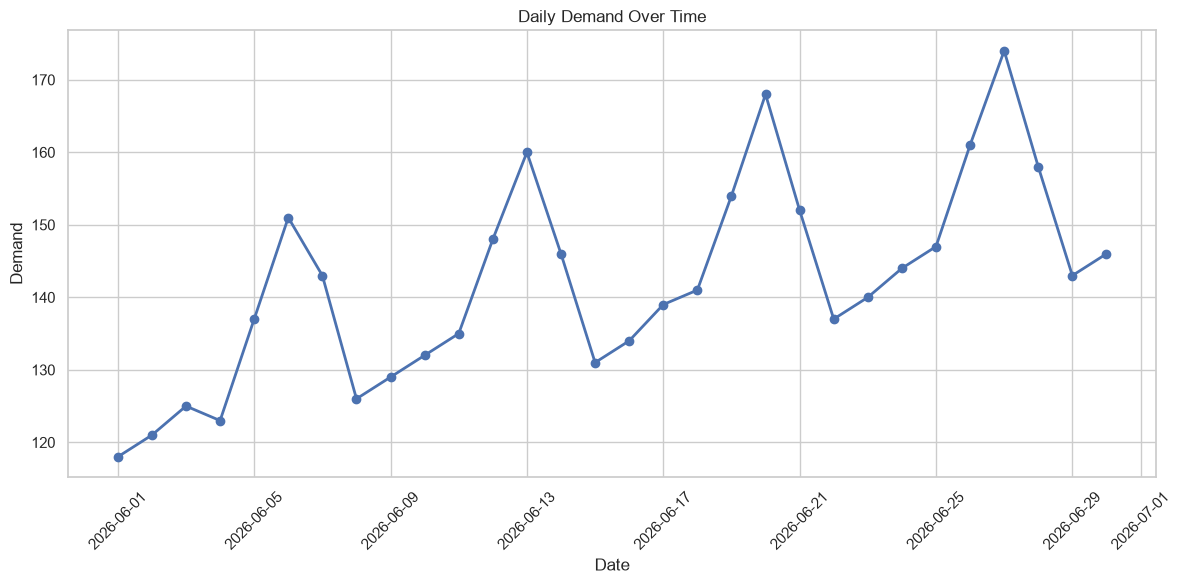

In [3]:
# Step 3: Exploratory Data Analysis

print("Demand Statistics")
print("=" * 50)

print(f"Mean Demand   : {df['demand'].mean():.2f}")
print(f"Median Demand : {df['demand'].median():.2f}")
print(f"Minimum Demand: {df['demand'].min():.2f}")
print(f"Maximum Demand: {df['demand'].max():.2f}")
print(f"Std. Deviation: {df['demand'].std():.2f}")

# Demand over time
plt.figure(figsize=(12, 6))

plt.plot(
    df["date"],
    df["demand"],
    marker="o",
    linewidth=2
)

plt.title("Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Average Demand by Marketing Event


,marketing_event,count,mean,min,max
0,0,22,136.818182,118,158
1,1,8,156.625000,137,174



Average Demand by Holiday


,holiday,count,mean,min,max
0,0,26,140.923077,118,174
1,1,4,149.750000,143,158


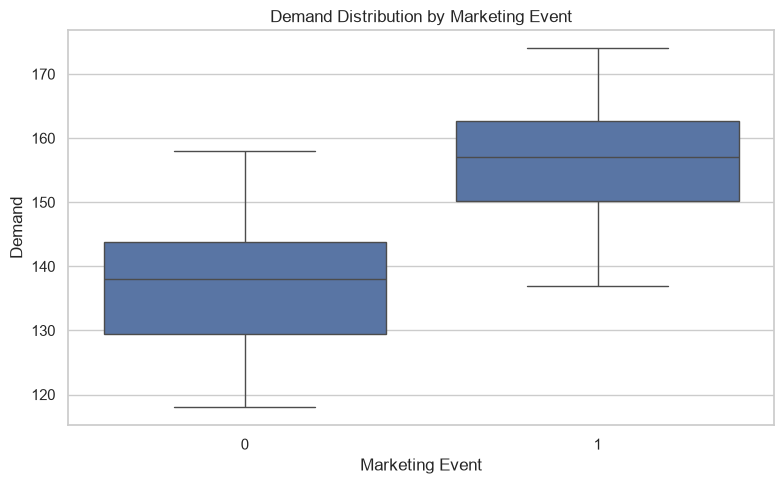

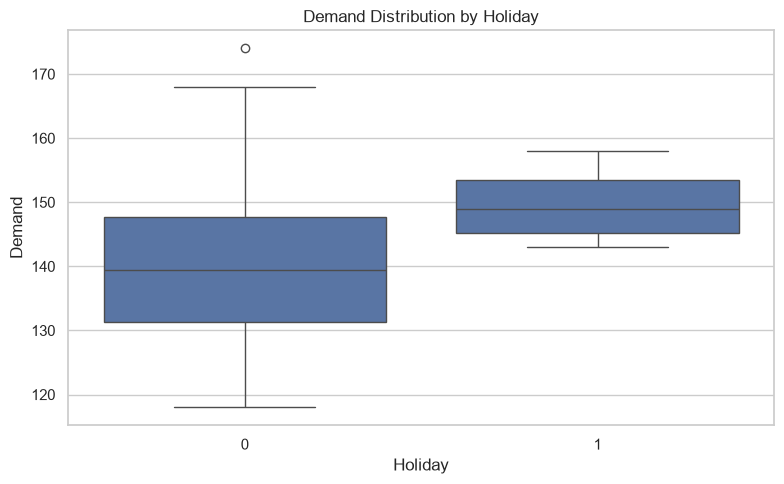

In [4]:
# Step 4: Analyze Marketing Events and Holidays

print("Average Demand by Marketing Event")
print("=" * 50)

marketing_summary = (
    df.groupby("marketing_event")["demand"]
    .agg(["count", "mean", "min", "max"])
    .reset_index()
)

display(marketing_summary)


print("\nAverage Demand by Holiday")
print("=" * 50)

holiday_summary = (
    df.groupby("holiday")["demand"]
    .agg(["count", "mean", "min", "max"])
    .reset_index()
)

display(holiday_summary)


# Visualization: Marketing Event
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="marketing_event",
    y="demand"
)

plt.title("Demand Distribution by Marketing Event")
plt.xlabel("Marketing Event")
plt.ylabel("Demand")
plt.tight_layout()
plt.show()


# Visualization: Holiday
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="holiday",
    y="demand"
)

plt.title("Demand Distribution by Holiday")
plt.xlabel("Holiday")
plt.ylabel("Demand")
plt.tight_layout()
plt.show()

In [6]:
# Step 5: Feature Engineering for Predictive Modeling

model_df = df.copy()

# Calendar features
model_df["day_of_week"] = model_df["date"].dt.dayofweek
model_df["day_of_month"] = model_df["date"].dt.day
model_df["month"] = model_df["date"].dt.month
model_df["week_of_year"] = model_df["date"].dt.isocalendar().week.astype(int)

# Lag features
model_df["lag_1"] = model_df["demand"].shift(1)
model_df["lag_7"] = model_df["demand"].shift(7)

# Rolling features using only previous observations
model_df["rolling_mean_7"] = (
    model_df["demand"]
    .shift(1)
    .rolling(window=7)
    .mean()
)

model_df["rolling_std_7"] = (
    model_df["demand"]
    .shift(1)
    .rolling(window=7)
    .std()
)

# Remove rows created with missing lag/rolling values
model_df = model_df.dropna().reset_index(drop=True)

print("Feature engineering completed.")
print(f"Original rows: {len(df)}")
print(f"Rows after feature engineering: {len(model_df)}")

display(model_df.head())

Feature engineering completed.
Original rows: 30
Rows after feature engineering: 23


,date,demand,marketing_event,holiday,day_of_week,day_of_month,month,week_of_year,lag_1,lag_7,rolling_mean_7,rolling_std_7
0,2026-06-08,126,0,0,0,8,6,24,143.0,118.0,131.142857,12.575486
1,2026-06-09,129,0,0,1,9,6,24,126.0,121.0,132.285714,11.499482
2,2026-06-10,132,0,0,2,10,6,24,129.0,125.0,133.428571,10.549204
3,2026-06-11,135,0,0,3,11,6,24,132.0,123.0,134.428571,9.930712
4,2026-06-12,148,1,0,4,12,6,24,135.0,137.0,136.142857,8.571825


In [9]:
# Step 6: Prepare Data for Predictive Modeling

# Features used for prediction
feature_columns = [
    "marketing_event",
    "holiday",
    "day_of_week",
    "day_of_month",
    "month",
    "week_of_year",
    "lag_1",
    "lag_7",
    "rolling_mean_7",
    "rolling_std_7"
]

X = model_df[feature_columns]
y = model_df["demand"]

# Time-ordered 80/20 split
split_index = int(len(model_df) * 0.8)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("Training and testing datasets prepared.")
print("=" * 50)
print(f"Total observations : {len(model_df)}")
print(f"Training samples   : {len(X_train)}")
print(f"Testing samples    : {len(X_test)}")
print(f"Number of features : {X_train.shape[1]}")

print("\nTraining period:")
print(
    model_df["date"].iloc[0],
    "to",
    model_df["date"].iloc[split_index - 1]
)

print("\nTesting period:")
print(
    model_df["date"].iloc[split_index],
    "to",
    model_df["date"].iloc[-1]
)

Training and testing datasets prepared.
Total observations : 23
Training samples   : 18
Testing samples    : 5
Number of features : 10

Training period:
2026-06-08 00:00:00 to 2026-06-25 00:00:00

Testing period:
2026-06-26 00:00:00 to 2026-06-30 00:00:00


In [10]:
# Step 7: Naive Baseline Forecast

# Predict each test value using the previous day's actual demand
baseline_predictions = model_df["demand"].shift(1).iloc[split_index:].values

# Actual test values
baseline_actual = y_test.values

print("Naive baseline forecast created.")
print(f"Test observations: {len(baseline_actual)}")

baseline_results = pd.DataFrame({
    "date": model_df["date"].iloc[split_index:].values,
    "actual_demand": baseline_actual,
    "baseline_prediction": baseline_predictions
})

display(baseline_results)

Naive baseline forecast created.
Test observations: 5


,date,actual_demand,baseline_prediction
0,2026-06-26,161,147.0
1,2026-06-27,174,161.0
2,2026-06-28,158,174.0
3,2026-06-29,143,158.0
4,2026-06-30,146,143.0


In [11]:
# Step 8: Evaluate Naive Baseline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

baseline_mae = mean_absolute_error(
    baseline_actual,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        baseline_actual,
        baseline_predictions
    )
)

baseline_mape = (
    mean_absolute_percentage_error(
        baseline_actual,
        baseline_predictions
    ) * 100
)

baseline_metrics = pd.DataFrame({
    "Model": ["Naive Baseline"],
    "MAE": [baseline_mae],
    "RMSE": [baseline_rmse],
    "MAPE (%)": [baseline_mape]
})

print("Baseline Model Performance")
print("=" * 50)

display(baseline_metrics)

Baseline Model Performance


,Model,MAE,RMSE,MAPE (%)
0,Naive Baseline,12.2,13.076697,7.767561


In [12]:
# Step 9: Random Forest Regression Model

from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Generate predictions
rf_predictions = rf_model.predict(X_test)

print("Random Forest model trained successfully.")
print(f"Predictions generated: {len(rf_predictions)}")

# Display predictions
rf_results = pd.DataFrame({
    "date": model_df["date"].iloc[split_index:].values,
    "actual_demand": y_test.values,
    "predicted_demand": rf_predictions
})

display(rf_results)

Random Forest model trained successfully.
Predictions generated: 5


,date,actual_demand,predicted_demand
0,2026-06-26,161,158.47500
1,2026-06-27,174,162.22000
2,2026-06-28,158,156.76000
3,2026-06-29,143,144.14375
4,2026-06-30,146,144.79750


In [13]:
# Step 10: Evaluate Random Forest Model

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_mape = (
    mean_absolute_percentage_error(
        y_test,
        rf_predictions
    ) * 100
)

rf_metrics = pd.DataFrame({
    "Model": ["Random Forest"],
    "MAE": [rf_mae],
    "RMSE": [rf_rmse],
    "MAPE (%)": [rf_mape]
})

print("Random Forest Model Performance")
print("=" * 50)

display(rf_metrics)

Random Forest Model Performance


,Model,MAE,RMSE,MAPE (%)
0,Random Forest,3.57825,5.466915,2.149341


In [14]:
# Step 11: Gradient Boosting Regression Model

from sklearn.ensemble import GradientBoostingRegressor

# Create Gradient Boosting model
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    random_state=42
)

# Train the model
gb_model.fit(X_train, y_train)

# Generate predictions
gb_predictions = gb_model.predict(X_test)

print("Gradient Boosting model trained successfully.")
print(f"Predictions generated: {len(gb_predictions)}")

# Display predictions
gb_results = pd.DataFrame({
    "date": model_df["date"].iloc[split_index:].values,
    "actual_demand": y_test.values,
    "predicted_demand": gb_predictions
})

display(gb_results)

Gradient Boosting model trained successfully.
Predictions generated: 5


,date,actual_demand,predicted_demand
0,2026-06-26,161,160.418879
1,2026-06-27,174,167.340677
2,2026-06-28,158,159.220513
3,2026-06-29,143,144.156031
4,2026-06-30,146,144.385506


In [15]:
# Step 12: Evaluate Gradient Boosting Model

gb_mae = mean_absolute_error(
    y_test,
    gb_predictions
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gb_predictions
    )
)

gb_mape = (
    mean_absolute_percentage_error(
        y_test,
        gb_predictions
    ) * 100
)

gb_metrics = pd.DataFrame({
    "Model": ["Gradient Boosting"],
    "MAE": [gb_mae],
    "RMSE": [gb_rmse],
    "MAPE (%)": [gb_mape]
})

print("Gradient Boosting Model Performance")
print("=" * 50)

display(gb_metrics)

Gradient Boosting Model Performance


,Model,MAE,RMSE,MAPE (%)
0,Gradient Boosting,2.246296,3.165973,1.37497


In [16]:
# Step 13: Compare Baseline and Machine Learning Models

model_comparison = pd.concat(
    [
        baseline_metrics,
        rf_metrics,
        gb_metrics
    ],
    ignore_index=True
)

model_comparison = model_comparison.sort_values(
    by="RMSE"
).reset_index(drop=True)

print("Model Performance Comparison")
print("=" * 50)

display(model_comparison)

Model Performance Comparison


,Model,MAE,RMSE,MAPE (%)
0,Gradient Boosting,2.246296,3.165973,1.374970
1,Random Forest,3.578250,5.466915,2.149341
2,Naive Baseline,12.200000,13.076697,7.767561


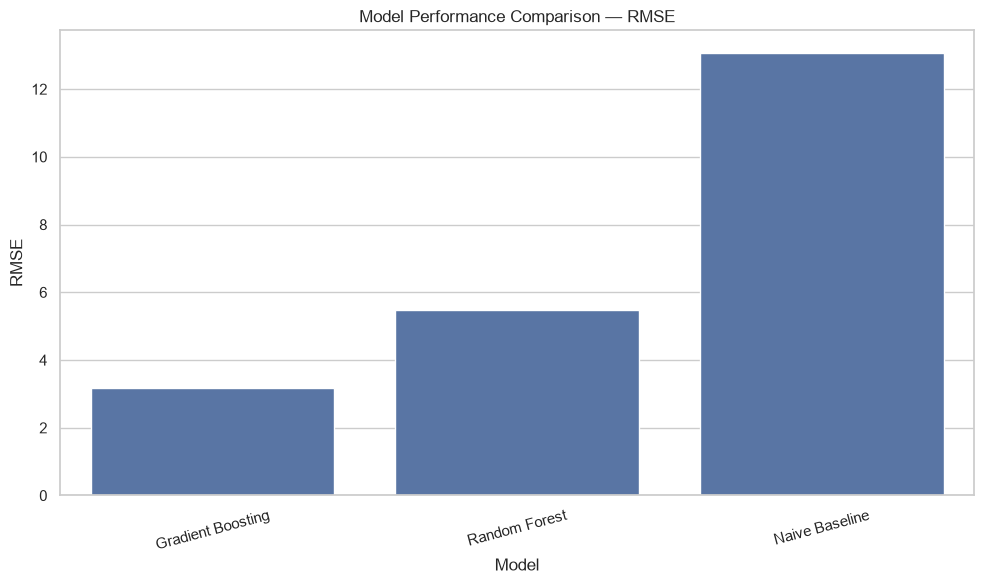

In [17]:
# Step 14: Visualize Model Performance

plt.figure(figsize=(10, 6))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="RMSE"
)

plt.title("Model Performance Comparison — RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Random Forest Feature Importance


,Feature,Importance
0,lag_7,0.732122
1,day_of_week,0.112202
2,marketing_event,0.045931
3,day_of_month,0.038077
4,rolling_mean_7,0.029758
5,rolling_std_7,0.018874
6,lag_1,0.017873
7,week_of_year,0.004588
8,holiday,0.000574
9,month,0.000000


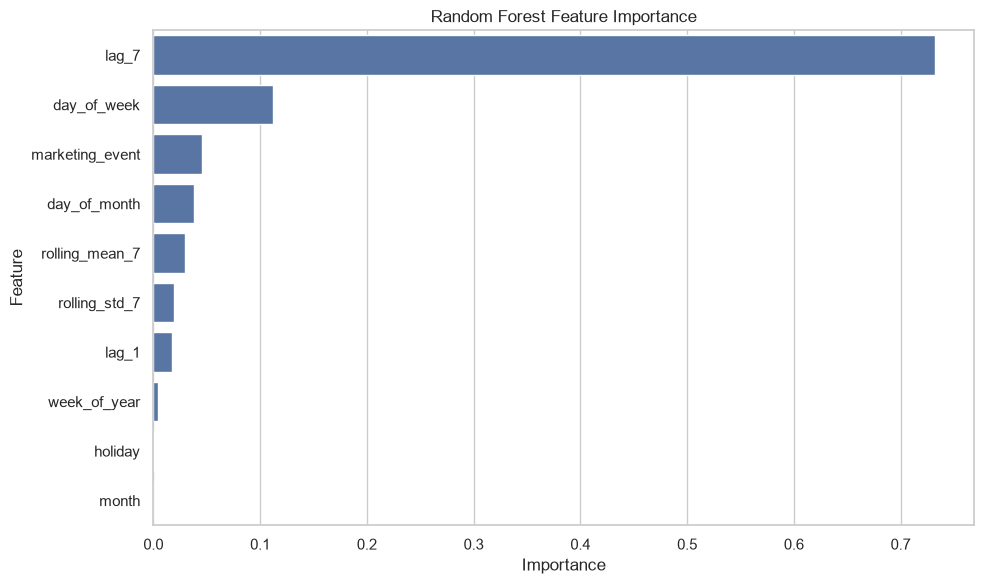

In [18]:
# Step 15: Random Forest Feature Importance

feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Random Forest Feature Importance")
print("=" * 50)

display(feature_importance)


# Visualization
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [19]:
# Step 16: ARIMA Statistical Forecasting Model

from statsmodels.tsa.arima.model import ARIMA

# Use the original demand series for ARIMA
demand_series = df.set_index("date")["demand"]

# Same chronological 80/20 split
arima_split = int(len(demand_series) * 0.8)

arima_train = demand_series.iloc[:arima_split]
arima_test = demand_series.iloc[arima_split:]

# Fit ARIMA model
arima_model = ARIMA(
    arima_train,
    order=(1, 1, 0)
)

arima_fit = arima_model.fit()

# Forecast the test period
arima_predictions = arima_fit.forecast(
    steps=len(arima_test)
)

print("ARIMA model trained successfully.")
print(f"Training observations: {len(arima_train)}")
print(f"Testing observations : {len(arima_test)}")

display(
    pd.DataFrame({
        "date": arima_test.index,
        "actual_demand": arima_test.values,
        "predicted_demand": arima_predictions.values
    })
)

ARIMA model trained successfully.
Training observations: 24
Testing observations : 6


C:\Users\jaris\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\jaris\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\jaris\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


,date,actual_demand,predicted_demand
0,2026-06-25,147,144.904700
1,2026-06-26,161,145.109320
2,2026-06-27,174,145.155601
3,2026-06-28,158,145.166068
4,2026-06-29,143,145.168435
5,2026-06-30,146,145.168971


In [20]:
# Step 17: Evaluate ARIMA Model

arima_mae = mean_absolute_error(
    arima_test,
    arima_predictions
)

arima_rmse = np.sqrt(
    mean_squared_error(
        arima_test,
        arima_predictions
    )
)

arima_mape = (
    mean_absolute_percentage_error(
        arima_test,
        arima_predictions
    ) * 100
)

arima_metrics = pd.DataFrame({
    "Model": ["ARIMA"],
    "MAE": [arima_mae],
    "RMSE": [arima_rmse],
    "MAPE (%)": [arima_mape]
})

print("ARIMA Model Performance")
print("=" * 50)

display(arima_metrics)

ARIMA Model Performance


,Model,MAE,RMSE,MAPE (%)
0,ARIMA,10.443963,14.485659,6.346822


In [21]:
# Step 18: Complete Model Comparison

model_comparison = pd.concat(
    [
        baseline_metrics,
        arima_metrics,
        rf_metrics,
        gb_metrics
    ],
    ignore_index=True
)

model_comparison = model_comparison.sort_values(
    by="RMSE"
).reset_index(drop=True)

print("Complete Model Performance Comparison")
print("=" * 60)

display(model_comparison)

Complete Model Performance Comparison


,Model,MAE,RMSE,MAPE (%)
0,Gradient Boosting,2.246296,3.165973,1.374970
1,Random Forest,3.578250,5.466915,2.149341
2,Naive Baseline,12.200000,13.076697,7.767561
3,ARIMA,10.443963,14.485659,6.346822


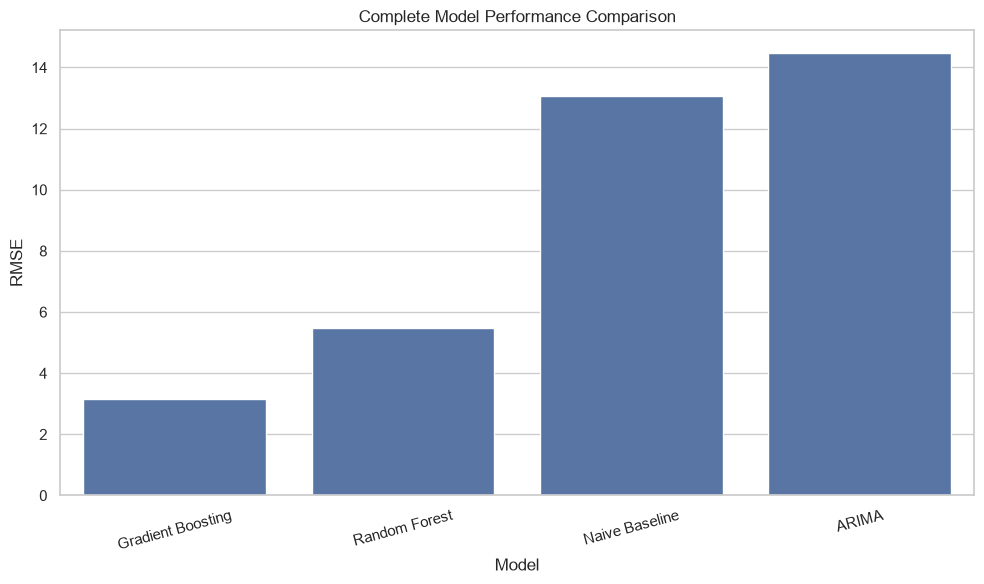

In [22]:
# Step 19: Complete Model Performance Visualization

plt.figure(figsize=(10, 6))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="RMSE"
)

plt.title("Complete Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

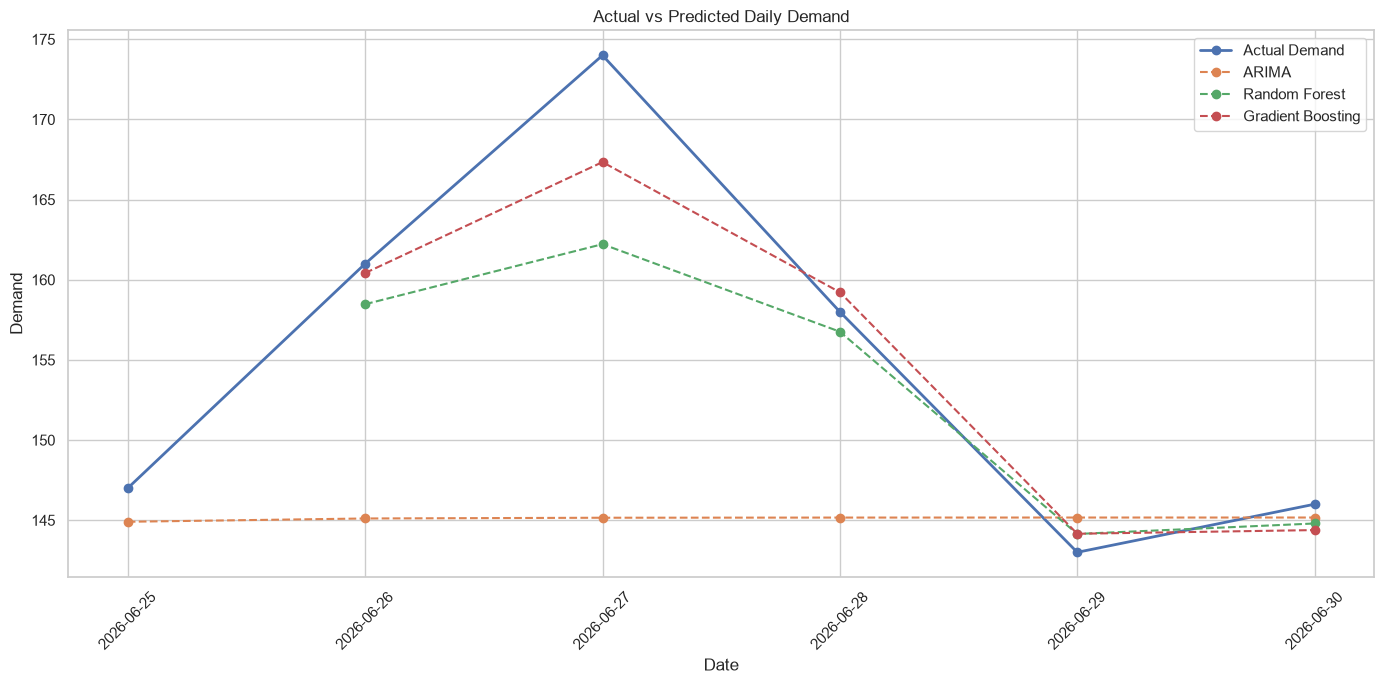

In [23]:
# Step 20: Actual vs Predicted Demand

plt.figure(figsize=(14, 7))

plt.plot(
    arima_test.index,
    arima_test.values,
    marker="o",
    linewidth=2,
    label="Actual Demand"
)

plt.plot(
    arima_test.index,
    arima_predictions.values,
    marker="o",
    linestyle="--",
    label="ARIMA"
)

plt.plot(
    model_df["date"].iloc[split_index:],
    rf_predictions,
    marker="o",
    linestyle="--",
    label="Random Forest"
)

plt.plot(
    model_df["date"].iloc[split_index:],
    gb_predictions,
    marker="o",
    linestyle="--",
    label="Gradient Boosting"
)

plt.title("Actual vs Predicted Daily Demand")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
# Step 21: Save Research Results

results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

# Save model comparison
model_comparison.to_csv(
    results_dir / "task6_model_comparison.csv",
    index=False
)

# Save feature importance
feature_importance.to_csv(
    results_dir / "task6_feature_importance.csv",
    index=False
)

# Save baseline predictions
baseline_results.to_csv(
    results_dir / "task6_baseline_predictions.csv",
    index=False
)

# Save Random Forest predictions
rf_results.to_csv(
    results_dir / "task6_random_forest_predictions.csv",
    index=False
)

# Save Gradient Boosting predictions
gb_results.to_csv(
    results_dir / "task6_gradient_boosting_predictions.csv",
    index=False
)

# Save ARIMA predictions
arima_results = pd.DataFrame({
    "date": arima_test.index,
    "actual_demand": arima_test.values,
    "arima_prediction": arima_predictions.values
})

arima_results.to_csv(
    results_dir / "task6_arima_predictions.csv",
    index=False
)

print("Research results saved successfully!")

for file in sorted(results_dir.glob("*.csv")):
    print("-", file.name)

Research results saved successfully!
- task6_arima_predictions.csv
- task6_baseline_predictions.csv
- task6_feature_importance.csv
- task6_gradient_boosting_predictions.csv
- task6_model_comparison.csv
- task6_random_forest_predictions.csv


In [25]:
# Step 22: Save Research Plots

plots_dir = Path("../plots")
plots_dir.mkdir(exist_ok=True)

# 1. Daily Demand Trend
plt.figure(figsize=(12, 6))
plt.plot(
    df["date"],
    df["demand"],
    marker="o",
    linewidth=2
)
plt.title("Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    plots_dir / "task6_daily_demand_trend.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()


# 2. Demand by Marketing Event
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="marketing_event",
    y="demand"
)
plt.title("Demand Distribution by Marketing Event")
plt.xlabel("Marketing Event")
plt.ylabel("Demand")
plt.tight_layout()
plt.savefig(
    plots_dir / "task6_demand_by_marketing_event.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()


# 3. Demand by Holiday
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="holiday",
    y="demand"
)
plt.title("Demand Distribution by Holiday")
plt.xlabel("Holiday")
plt.ylabel("Demand")
plt.tight_layout()
plt.savefig(
    plots_dir / "task6_demand_by_holiday.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()


# 4. Model RMSE Comparison
plt.figure(figsize=(10, 6))
sns.barplot(
    data=model_comparison,
    x="Model",
    y="RMSE"
)
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(
    plots_dir / "task6_model_rmse_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()


# 5. Actual vs Predicted Demand
plt.figure(figsize=(14, 7))

plt.plot(
    arima_test.index,
    arima_test.values,
    marker="o",
    linewidth=2,
    label="Actual Demand"
)

plt.plot(
    arima_test.index,
    arima_predictions.values,
    marker="o",
    linestyle="--",
    label="ARIMA"
)

plt.plot(
    model_df["date"].iloc[split_index:],
    rf_predictions,
    marker="o",
    linestyle="--",
    label="Random Forest"
)

plt.plot(
    model_df["date"].iloc[split_index:],
    gb_predictions,
    marker="o",
    linestyle="--",
    label="Gradient Boosting"
)

plt.title("Actual vs Predicted Daily Demand")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    plots_dir / "task6_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()


# 6. Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(
    plots_dir / "task6_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()


print("All research plots saved successfully!")

for plot_file in sorted(plots_dir.glob("*.png")):
    print("-", plot_file.name)

All research plots saved successfully!
- task6_actual_vs_predicted.png
- task6_daily_demand_trend.png
- task6_demand_by_holiday.png
- task6_demand_by_marketing_event.png
- task6_feature_importance.png
- task6_model_rmse_comparison.png


## 2. Time-Series Analysis

### Time-Series Decomposition

To understand the underlying structure of daily demand, the time series will be decomposed into:

- Observed component
- Trend component
- Seasonal component
- Residual component

An additive decomposition with a 7-day seasonal period is used because the dataset represents daily observations and weekly patterns may influence demand.

The decomposition helps identify whether demand changes are primarily associated with long-term trends, weekly seasonality, or irregular variations.

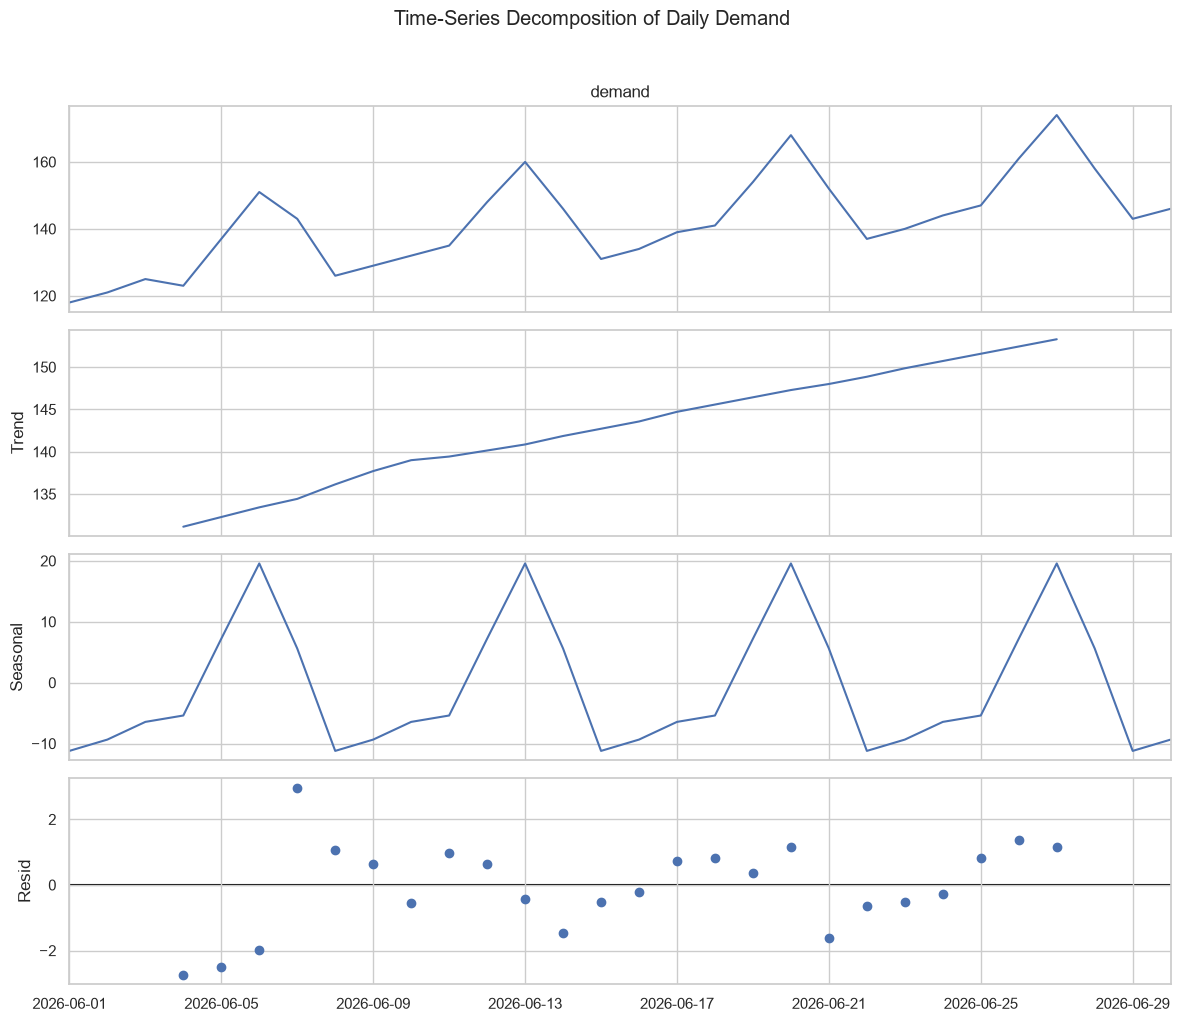

In [26]:
# Step 23: Time-Series Decomposition

from statsmodels.tsa.seasonal import seasonal_decompose

# Create time-indexed demand series
demand_series = df.set_index("date")["demand"]

# Perform additive decomposition
decomposition = seasonal_decompose(
    demand_series,
    model="additive",
    period=7
)

# Display decomposition
fig = decomposition.plot()
fig.set_size_inches(12, 10)

plt.suptitle(
    "Time-Series Decomposition of Daily Demand",
    y=1.02
)

plt.tight_layout()
plt.show()

In [27]:
# Step 24: Augmented Dickey-Fuller Stationarity Test

from statsmodels.tsa.stattools import adfuller

# ADF test on original demand series
adf_result = adfuller(demand_series.dropna())

adf_statistic = adf_result[0]
adf_pvalue = adf_result[1]

print("Augmented Dickey-Fuller Test")
print("=" * 50)
print(f"ADF Statistic : {adf_statistic:.4f}")
print(f"p-value       : {adf_pvalue:.6f}")

print("\nHypotheses:")
print("H0: The time series is non-stationary.")
print("H1: The time series is stationary.")

if adf_pvalue < 0.05:
    print("\nConclusion: Reject H0.")
    print("The demand series is stationary at the 5% significance level.")
else:
    print("\nConclusion: Fail to reject H0.")
    print("The demand series is non-stationary at the 5% significance level.")

Augmented Dickey-Fuller Test
ADF Statistic : -0.9039
p-value       : 0.786695

Hypotheses:
H0: The time series is non-stationary.
H1: The time series is stationary.

Conclusion: Fail to reject H0.
The demand series is non-stationary at the 5% significance level.


C:\Users\jaris\AppData\Local\Temp\ipykernel_17780\2989369655.py:6: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(demand_series.dropna())


In [28]:
# Step 25: First-Order Differencing and Stationarity Test

# Apply first-order differencing
demand_diff = demand_series.diff().dropna()

# ADF test on differenced series
adf_diff_result = adfuller(demand_diff)

adf_diff_statistic = adf_diff_result[0]
adf_diff_pvalue = adf_diff_result[1]

print("ADF Test After First-Order Differencing")
print("=" * 50)
print(f"ADF Statistic : {adf_diff_statistic:.4f}")
print(f"p-value       : {adf_diff_pvalue:.6f}")

print("\nHypotheses:")
print("H0: The differenced series is non-stationary.")
print("H1: The differenced series is stationary.")

if adf_diff_pvalue < 0.05:
    print("\nConclusion: Reject H0.")
    print("The differenced series is stationary at the 5% significance level.")
else:
    print("\nConclusion: Fail to reject H0.")
    print("The differenced series remains non-stationary.")

ADF Test After First-Order Differencing
ADF Statistic : -2.2336
p-value       : 0.194269

Hypotheses:
H0: The differenced series is non-stationary.
H1: The differenced series is stationary.

Conclusion: Fail to reject H0.
The differenced series remains non-stationary.


C:\Users\jaris\AppData\Local\Temp\ipykernel_17780\3037980691.py:7: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_diff_result = adfuller(demand_diff)


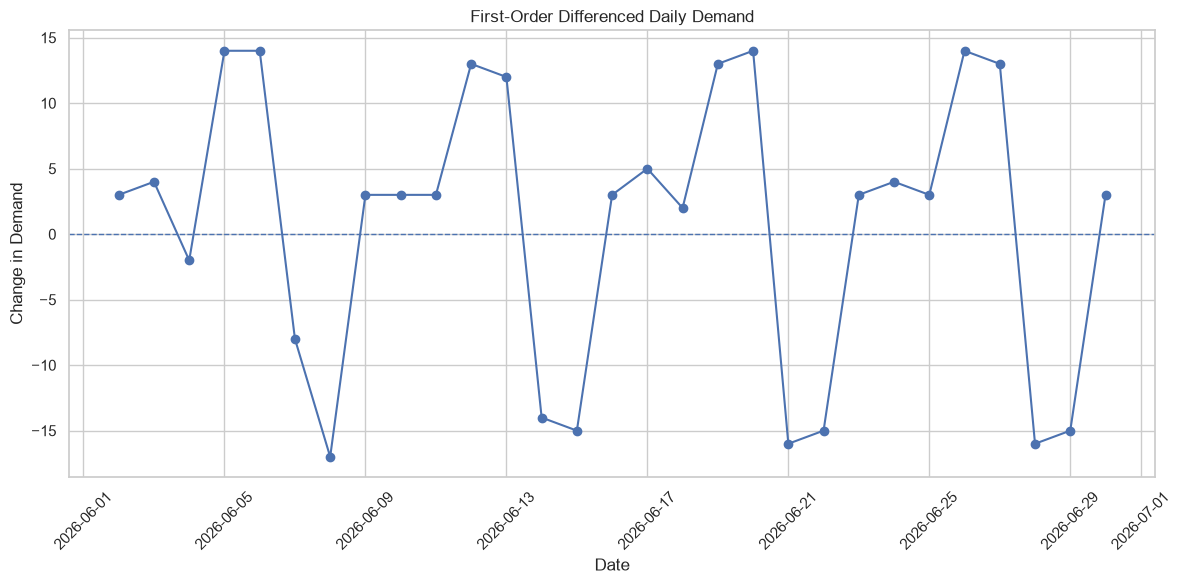

In [29]:
# Step 26: Visualize Differenced Demand

plt.figure(figsize=(12, 6))

plt.plot(
    demand_diff.index,
    demand_diff.values,
    marker="o"
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title("First-Order Differenced Daily Demand")
plt.xlabel("Date")
plt.ylabel("Change in Demand")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Average Demand by Day of Week


,day_number,day_name,demand
0,0,Monday,131.00
1,1,Tuesday,134.00
2,2,Wednesday,135.00
3,3,Thursday,136.50
4,4,Friday,150.00
5,5,Saturday,163.25
6,6,Sunday,149.75


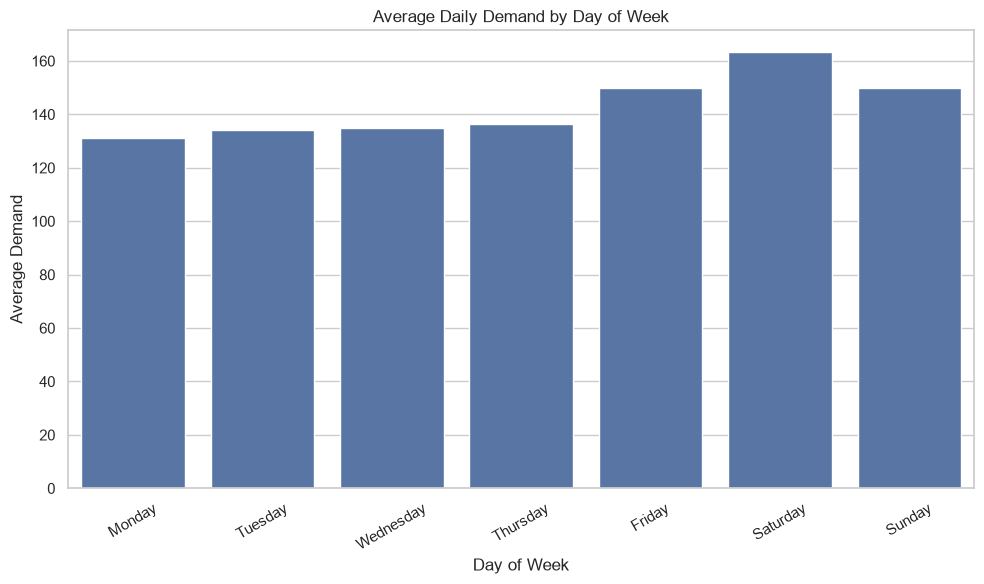

In [30]:
# Step 27: Weekly Seasonality Analysis

# Extract day of week
seasonality_df = df.copy()
seasonality_df["day_name"] = seasonality_df["date"].dt.day_name()
seasonality_df["day_number"] = seasonality_df["date"].dt.dayofweek

# Calculate average demand by day of week
weekly_demand = (
    seasonality_df
    .groupby(["day_number", "day_name"])["demand"]
    .mean()
    .reset_index()
    .sort_values("day_number")
)

print("Average Demand by Day of Week")
print("=" * 50)

display(weekly_demand)


# Visualization
plt.figure(figsize=(10, 6))

sns.barplot(
    data=weekly_demand,
    x="day_name",
    y="demand"
)

plt.title("Average Daily Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Demand")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Correlation Matrix


,demand,day_of_week,day_of_month,month,week_of_year,lag_1,lag_7,rolling_mean_7,rolling_std_7
demand,1.000,0.755,0.534,NaN,0.297,0.598,0.988,0.552,-0.231
day_of_week,0.755,1.000,0.103,NaN,-0.202,0.530,0.736,0.131,-0.335
day_of_month,0.534,0.103,1.000,NaN,0.953,0.545,0.593,0.997,0.381
month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
week_of_year,0.297,-0.202,0.953,NaN,1.000,0.376,0.361,0.941,0.477
lag_1,0.598,0.530,0.545,NaN,0.376,1.000,0.645,0.563,0.505
lag_7,0.988,0.736,0.593,NaN,0.361,0.645,1.000,0.616,-0.141
rolling_mean_7,0.552,0.131,0.997,NaN,0.941,0.563,0.616,1.000,0.371
rolling_std_7,-0.231,-0.335,0.381,NaN,0.477,0.505,-0.141,0.371,1.000


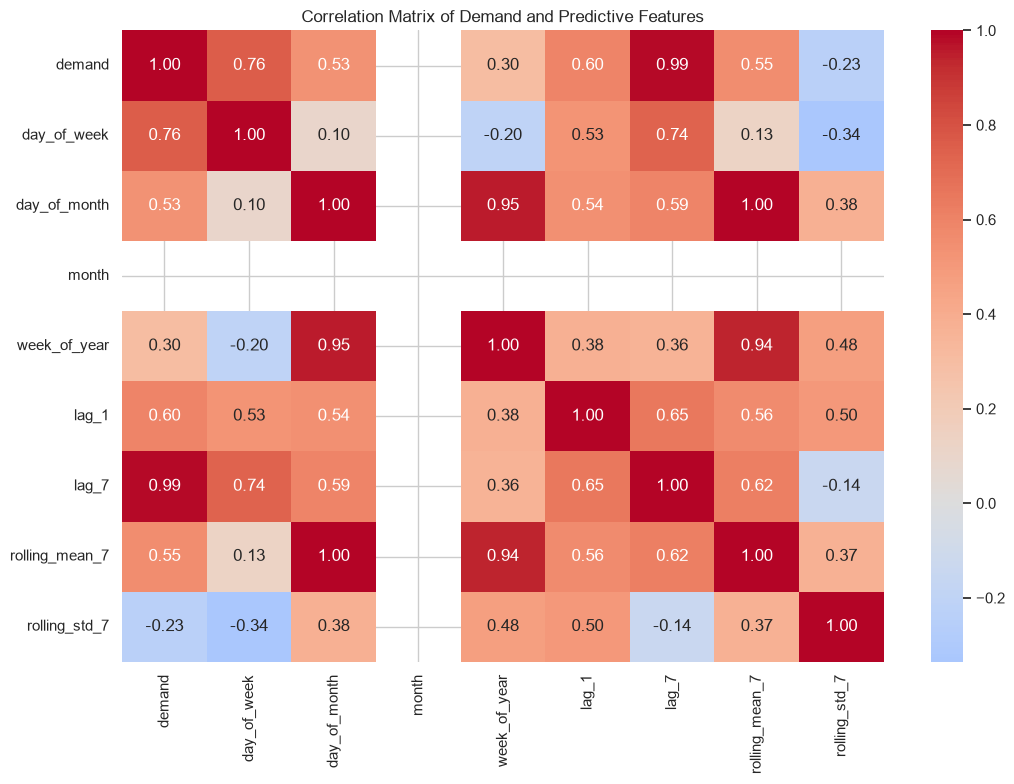

In [31]:
# Step 28: Correlation Analysis

# Select numerical variables
correlation_columns = [
    "demand",
    "day_of_week",
    "day_of_month",
    "month",
    "week_of_year",
    "lag_1",
    "lag_7",
    "rolling_mean_7",
    "rolling_std_7"
]

correlation_matrix = model_df[correlation_columns].corr()

print("Correlation Matrix")
print("=" * 50)

display(correlation_matrix.round(3))


# Heatmap
plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Demand and Predictive Features")
plt.tight_layout()
plt.show()

In [32]:
# Step 29: Save Day 2 Research Results

results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

# ADF results
adf_results = pd.DataFrame({
    "Test": [
        "ADF - Original Series",
        "ADF - First Difference"
    ],
    "Statistic": [
        adf_statistic,
        adf_diff_statistic
    ],
    "p_value": [
        adf_pvalue,
        adf_diff_pvalue
    ]
})

adf_results.to_csv(
    results_dir / "task6_adf_stationarity_results.csv",
    index=False
)

# Weekly seasonality results
weekly_demand.to_csv(
    results_dir / "task6_weekly_seasonality.csv",
    index=False
)

# Correlation matrix
correlation_matrix.to_csv(
    results_dir / "task6_correlation_matrix.csv"
)

print("Day 2 analysis results saved successfully!")

print("\nSaved files:")
print("- task6_adf_stationarity_results.csv")
print("- task6_weekly_seasonality.csv")
print("- task6_correlation_matrix.csv")

Day 2 analysis results saved successfully!

Saved files:
- task6_adf_stationarity_results.csv
- task6_weekly_seasonality.csv
- task6_correlation_matrix.csv


In [33]:
# Step 30: Statistical Findings Summary

# Determine stationarity conclusions
original_stationary = adf_pvalue < 0.05
differenced_stationary = adf_diff_pvalue < 0.05

# Identify highest and lowest average demand days
highest_day = weekly_demand.loc[
    weekly_demand["demand"].idxmax()
]

lowest_day = weekly_demand.loc[
    weekly_demand["demand"].idxmin()
]

# Strongest correlation with demand
demand_correlations = (
    correlation_matrix["demand"]
    .drop("demand")
    .sort_values(key=abs, ascending=False)
)

strongest_feature = demand_correlations.index[0]
strongest_correlation = demand_correlations.iloc[0]

print("Statistical Findings Summary")
print("=" * 60)

print(f"Original series stationary: {original_stationary}")
print(f"Differenced series stationary: {differenced_stationary}")

print(
    f"\nHighest average demand day: "
    f"{highest_day['day_name']} "
    f"({highest_day['demand']:.2f})"
)

print(
    f"Lowest average demand day: "
    f"{lowest_day['day_name']} "
    f"({lowest_day['demand']:.2f})"
)

print(
    f"\nStrongest numerical relationship with demand: "
    f"{strongest_feature}"
)

print(
    f"Correlation with demand: "
    f"{strongest_correlation:.3f}"
)

Statistical Findings Summary
Original series stationary: False
Differenced series stationary: False

Highest average demand day: Saturday (163.25)
Lowest average demand day: Monday (131.00)

Strongest numerical relationship with demand: lag_7
Correlation with demand: 0.988


## 3. ARIMA Model Refinement and Hyperparameter Selection

### Objective

The initial analysis used an ARIMA(1,1,0) model as a statistical forecasting approach. However, selecting a forecasting model based on a single configuration may not provide sufficient evidence that the chosen model is appropriate.

Therefore, multiple ARIMA configurations will be systematically evaluated using the same training and testing datasets.

### ARIMA Hyperparameters

ARIMA is represented as:

**ARIMA(p, d, q)**

where:

- **p** = autoregressive order
- **d** = degree of differencing
- **q** = moving-average order

Based on the stationarity analysis performed earlier, first-order differencing (`d = 1`) will be used.

The following configurations will be evaluated:

- ARIMA(0,1,0)
- ARIMA(0,1,1)
- ARIMA(1,1,0)
- ARIMA(1,1,1)
- ARIMA(2,1,0)
- ARIMA(2,1,1)

### Model Selection Criteria

Each configuration will be evaluated using:

- **MAE (Mean Absolute Error)**
- **RMSE (Root Mean Squared Error)**
- **MAPE (Mean Absolute Percentage Error)**

The model with the **lowest RMSE on the held-out test set** will be selected as the preferred ARIMA configuration.

### Research Purpose

This systematic comparison provides evidence-based model selection rather than choosing an ARIMA configuration arbitrarily.

The selected ARIMA model will later be compared with the machine learning models developed in this research.

In [34]:
# Day 3 — Step 1: ARIMA Hyperparameter Selection

arima_orders = [
    (0, 1, 0),
    (0, 1, 1),
    (1, 1, 0),
    (1, 1, 1),
    (2, 1, 0),
    (2, 1, 1)
]

arima_results_list = []

for order in arima_orders:
    try:
        model = ARIMA(
            arima_train,
            order=order
        )

        fitted_model = model.fit()

        predictions = fitted_model.forecast(
            steps=len(arima_test)
        )

        mae = mean_absolute_error(
            arima_test,
            predictions
        )

        rmse = np.sqrt(
            mean_squared_error(
                arima_test,
                predictions
            )
        )

        mape = (
            mean_absolute_percentage_error(
                arima_test,
                predictions
            ) * 100
        )

        arima_results_list.append({
            "Order": str(order),
            "MAE": mae,
            "RMSE": rmse,
            "MAPE (%)": mape
        })

    except Exception as e:
        print(f"ARIMA{order} failed: {e}")

arima_comparison = pd.DataFrame(arima_results_list)

arima_comparison = arima_comparison.sort_values(
    by="RMSE"
).reset_index(drop=True)

print("ARIMA Hyperparameter Comparison")
print("=" * 60)

display(arima_comparison)

C:\Users\jaris\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\jaris\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\jaris\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\jaris\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\jaris\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: Val

ARIMA Hyperparameter Comparison


,Order,MAE,RMSE,MAPE (%)
0,"(1, 1, 0)",10.443963,14.485659,6.346822
1,"(0, 1, 1)",10.419898,14.496601,6.329457
2,"(1, 1, 1)",10.523464,14.620917,6.392775
3,"(0, 1, 0)",11.166667,15.269796,6.795188
4,"(2, 1, 0)",12.718981,17.173523,7.752457
5,"(2, 1, 1)",13.607062,17.561914,8.347725


In [35]:
# Day 3 — Step 2: Select Best ARIMA Model

best_arima_row = arima_comparison.iloc[0]

best_arima_order = tuple(
    int(value.strip())
    for value in best_arima_row["Order"].strip("()").split(",")
)

print("Best ARIMA Configuration")
print("=" * 50)
print("Order:", best_arima_order)
print(f"MAE: {best_arima_row['MAE']:.4f}")
print(f"RMSE: {best_arima_row['RMSE']:.4f}")
print(f"MAPE: {best_arima_row['MAPE (%)']:.2f}%")

Best ARIMA Configuration
Order: (1, 1, 0)
MAE: 10.4440
RMSE: 14.4857
MAPE: 6.35%


In [36]:
# Day 3 — Step 3: Validate Selected ARIMA Model

selected_arima_model = ARIMA(
    arima_train,
    order=best_arima_order
)

selected_arima_fit = selected_arima_model.fit()

selected_arima_predictions = selected_arima_fit.forecast(
    steps=len(arima_test)
)

selected_arima_mae = mean_absolute_error(
    arima_test,
    selected_arima_predictions
)

selected_arima_rmse = np.sqrt(
    mean_squared_error(
        arima_test,
        selected_arima_predictions
    )
)

selected_arima_mape = (
    mean_absolute_percentage_error(
        arima_test,
        selected_arima_predictions
    ) * 100
)

selected_arima_metrics = pd.DataFrame({
    "Model": ["Selected ARIMA"],
    "Order": [str(best_arima_order)],
    "MAE": [selected_arima_mae],
    "RMSE": [selected_arima_rmse],
    "MAPE (%)": [selected_arima_mape]
})

print("Selected ARIMA Validation Results")
print("=" * 55)

display(selected_arima_metrics)

Selected ARIMA Validation Results


C:\Users\jaris\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\jaris\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\jaris\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


,Model,Order,MAE,RMSE,MAPE (%)
0,Selected ARIMA,"(1, 1, 0)",10.443963,14.485659,6.346822


In [37]:
# Day 3 — Step 4: SARIMA Model

from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_order = (1, 1, 0)
sarima_seasonal_order = (1, 0, 0, 7)

sarima_model = SARIMAX(
    arima_train,
    order=sarima_order,
    seasonal_order=sarima_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

sarima_predictions = sarima_fit.forecast(
    steps=len(arima_test)
)

sarima_mae = mean_absolute_error(
    arima_test,
    sarima_predictions
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        arima_test,
        sarima_predictions
    )
)

sarima_mape = (
    mean_absolute_percentage_error(
        arima_test,
        sarima_predictions
    ) * 100
)

sarima_metrics = pd.DataFrame({
    "Model": ["SARIMA"],
    "MAE": [sarima_mae],
    "RMSE": [sarima_rmse],
    "MAPE (%)": [sarima_mape]
})

print("SARIMA Model Performance")
print("=" * 50)
print("Order:", sarima_order)
print("Seasonal Order:", sarima_seasonal_order)

display(sarima_metrics)

SARIMA Model Performance
Order: (1, 1, 0)
Seasonal Order: (1, 0, 0, 7)


C:\Users\jaris\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\jaris\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\jaris\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


,Model,MAE,RMSE,MAPE (%)
0,SARIMA,0.888728,0.962242,0.577406


In [38]:
# Day 3 — Step 5: Compare ARIMA and SARIMA

statistical_comparison = pd.concat(
    [
        selected_arima_metrics[
            ["Model", "MAE", "RMSE", "MAPE (%)"]
        ],
        sarima_metrics[
            ["Model", "MAE", "RMSE", "MAPE (%)"]
        ]
    ],
    ignore_index=True
)

statistical_comparison = statistical_comparison.sort_values(
    by="RMSE"
).reset_index(drop=True)

print("Statistical Model Comparison")
print("=" * 55)

display(statistical_comparison)

Statistical Model Comparison


,Model,MAE,RMSE,MAPE (%)
0,SARIMA,0.888728,0.962242,0.577406
1,Selected ARIMA,10.443963,14.485659,6.346822


In [39]:
# Day 3 — Step 6: Complete Predictive Model Comparison

all_model_metrics = pd.concat(
    [
        baseline_metrics,
        selected_arima_metrics[
            ["Model", "MAE", "RMSE", "MAPE (%)"]
        ],
        rf_metrics,
        gb_metrics,
        sarima_metrics
    ],
    ignore_index=True
)

all_model_metrics = all_model_metrics.sort_values(
    by="RMSE"
).reset_index(drop=True)

print("Complete Predictive Model Comparison")
print("=" * 65)

display(all_model_metrics)

# Identify best overall model
best_overall_model = all_model_metrics.iloc[0]

print("\nBest Overall Model")
print("=" * 40)
print("Model:", best_overall_model["Model"])
print(f"MAE: {best_overall_model['MAE']:.4f}")
print(f"RMSE: {best_overall_model['RMSE']:.4f}")
print(f"MAPE: {best_overall_model['MAPE (%)']:.2f}%")

Complete Predictive Model Comparison


,Model,MAE,RMSE,MAPE (%)
0,SARIMA,0.888728,0.962242,0.577406
1,Gradient Boosting,2.246296,3.165973,1.374970
2,Random Forest,3.578250,5.466915,2.149341
3,Naive Baseline,12.200000,13.076697,7.767561
4,Selected ARIMA,10.443963,14.485659,6.346822



Best Overall Model
Model: SARIMA
MAE: 0.8887
RMSE: 0.9622
MAPE: 0.58%


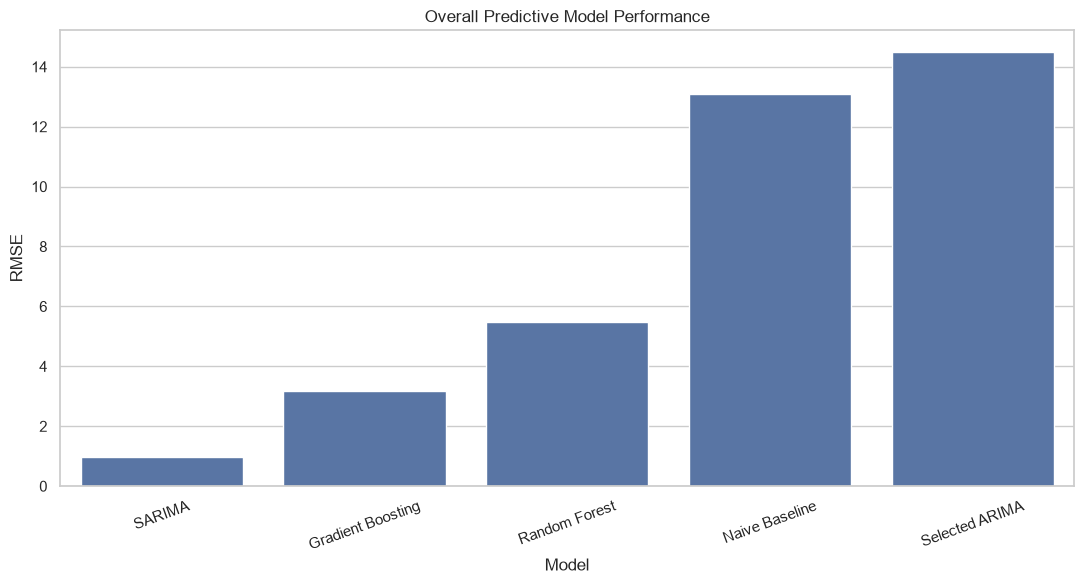

In [40]:
# Day 3 — Step 7: Visualize Complete Model Performance

plt.figure(figsize=(11, 6))

sns.barplot(
    data=all_model_metrics,
    x="Model",
    y="RMSE"
)

plt.title("Overall Predictive Model Performance")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [41]:
# Day 3 — Step 9: Save Refined Model Results

results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

# Save ARIMA hyperparameter comparison
arima_comparison.to_csv(
    results_dir / "task6_arima_hyperparameter_comparison.csv",
    index=False
)

# Save statistical model comparison
statistical_comparison.to_csv(
    results_dir / "task6_statistical_model_comparison.csv",
    index=False
)

# Save complete model comparison
all_model_metrics.to_csv(
    results_dir / "task6_complete_model_comparison.csv",
    index=False
)

print("Day 3 model evaluation results saved successfully!")

print("\nSaved files:")
print("- task6_arima_hyperparameter_comparison.csv")
print("- task6_statistical_model_comparison.csv")
print("- task6_complete_model_comparison.csv")

Day 3 model evaluation results saved successfully!

Saved files:
- task6_arima_hyperparameter_comparison.csv
- task6_statistical_model_comparison.csv
- task6_complete_model_comparison.csv


In [42]:
# Day 3 — Step 10: Select Final Predictive Model

final_model_row = all_model_metrics.iloc[0]

final_model_name = final_model_row["Model"]
final_mae = final_model_row["MAE"]
final_rmse = final_model_row["RMSE"]
final_mape = final_model_row["MAPE (%)"]

print("Final Predictive Model")
print("----------------------")
print(f"Model : {final_model_name}")
print(f"MAE   : {final_mae:.4f}")
print(f"RMSE  : {final_rmse:.4f}")
print(f"MAPE  : {final_mape:.2f}%")

print("\nSelection criterion: Lowest test-set RMSE.")

Final Predictive Model
----------------------
Model : SARIMA
MAE   : 0.8887
RMSE  : 0.9622
MAPE  : 0.58%

Selection criterion: Lowest test-set RMSE.


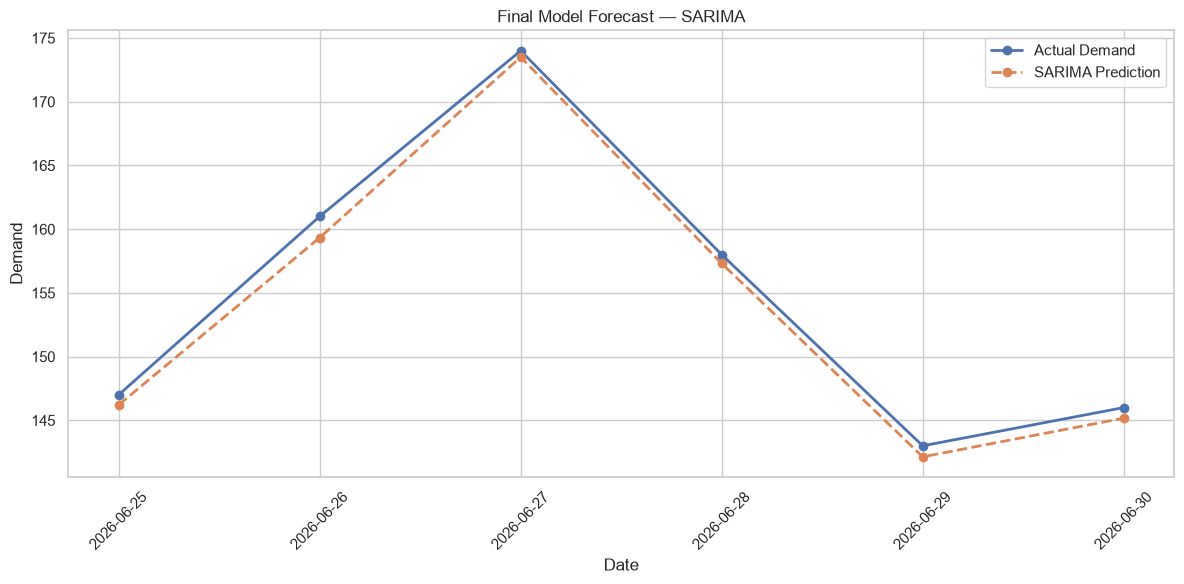

In [43]:
# Day 3 — Step 11: Final Model Forecast Visualization

# Get predictions from the selected model
if final_model_name == "Naive Baseline":
    final_predictions = baseline_predictions
elif final_model_name == "ARIMA":
    final_predictions = selected_arima_predictions
elif final_model_name == "SARIMA":
    final_predictions = sarima_predictions
elif final_model_name == "Random Forest":
    final_predictions = rf_predictions
elif final_model_name == "Gradient Boosting":
    final_predictions = gb_predictions
else:
    raise ValueError(f"Unknown final model: {final_model_name}")

plt.figure(figsize=(12, 6))

plt.plot(
    arima_test.index,
    arima_test.values,
    marker="o",
    linewidth=2,
    label="Actual Demand"
)

plt.plot(
    arima_test.index,
    np.asarray(final_predictions),
    marker="o",
    linestyle="--",
    linewidth=2,
    label=f"{final_model_name} Prediction"
)

plt.title(f"Final Model Forecast — {final_model_name}")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

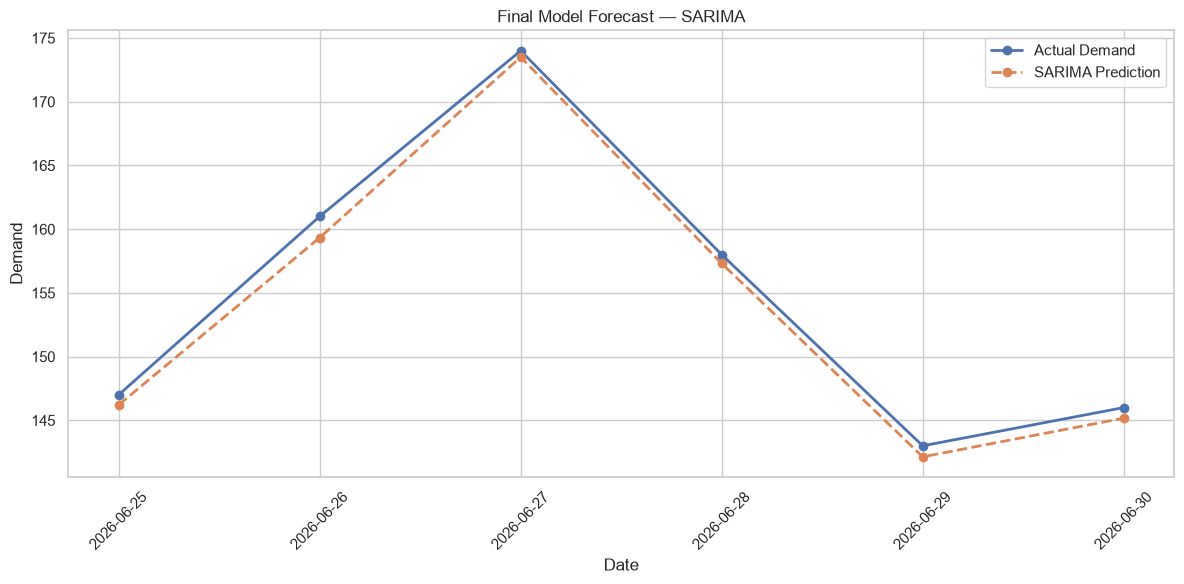

Final model plot saved to: ..\plots\task6_final_model_forecast.png


In [44]:
# Day 3 — Step 12: Save Final Model Plot

plots_dir = Path("../plots")
plots_dir.mkdir(exist_ok=True)

final_plot_path = plots_dir / "task6_final_model_forecast.png"

plt.figure(figsize=(12, 6))

plt.plot(
    arima_test.index,
    arima_test.values,
    marker="o",
    linewidth=2,
    label="Actual Demand"
)

plt.plot(
    arima_test.index,
    np.asarray(final_predictions),
    marker="o",
    linestyle="--",
    linewidth=2,
    label=f"{final_model_name} Prediction"
)

plt.title(f"Final Model Forecast — {final_model_name}")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(final_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Final model plot saved to: {final_plot_path}")

In [45]:
# Day 3 — Step 13: Create Final Prediction Results

final_prediction_results = pd.DataFrame({
    "Date": arima_test.index,
    "Actual Demand": np.asarray(arima_test.values),
    "Predicted Demand": np.asarray(final_predictions)
})

final_prediction_results["Prediction Error"] = (
    final_prediction_results["Actual Demand"]
    - final_prediction_results["Predicted Demand"]
)

final_prediction_results["Absolute Error"] = (
    final_prediction_results["Prediction Error"].abs()
)

final_prediction_results

,Date,Actual Demand,Predicted Demand,Prediction Error,Absolute Error
0,2026-06-25,147,146.210511,0.789489,0.789489
1,2026-06-26,161,159.332651,1.667349,1.667349
2,2026-06-27,174,173.505390,0.494610,0.494610
3,2026-06-28,158,157.313573,0.686427,0.686427
4,2026-06-29,143,142.134882,0.865118,0.865118
5,2026-06-30,146,145.170624,0.829376,0.829376


In [46]:
# Day 3 — Step 14: Save Final Prediction Results

final_prediction_path = results_dir / "task6_final_model_predictions.csv"

final_prediction_results.to_csv(
    final_prediction_path,
    index=False
)

print("Final prediction results saved successfully!")
print(f"File: {final_prediction_path}")

Final prediction results saved successfully!
File: ..\results\task6_final_model_predictions.csv


In [47]:
# Day 3 — Step 15: Generate Modeling Findings Summary

print("DAY 3 — MODELING FINDINGS")
print("=" * 50)

print(f"Best Overall Model: {final_model_name}")
print(f"MAE: {final_mae:.4f}")
print(f"RMSE: {final_rmse:.4f}")
print(f"MAPE: {final_mape:.2f}%")

print("\nModel Ranking by RMSE:")
display(
    all_model_metrics[
        ["Model", "MAE", "RMSE", "MAPE (%)"]
    ]
)

print("\nInterpretation:")
print(
    f"The {final_model_name} achieved the lowest test-set RMSE "
    f"among the evaluated models."
)

print(
    "The results should be interpreted cautiously because the dataset "
    "contains only a small number of observations."
)

DAY 3 — MODELING FINDINGS
Best Overall Model: SARIMA
MAE: 0.8887
RMSE: 0.9622
MAPE: 0.58%

Model Ranking by RMSE:


,Model,MAE,RMSE,MAPE (%)
0,SARIMA,0.888728,0.962242,0.577406
1,Gradient Boosting,2.246296,3.165973,1.374970
2,Random Forest,3.578250,5.466915,2.149341
3,Naive Baseline,12.200000,13.076697,7.767561
4,Selected ARIMA,10.443963,14.485659,6.346822



Interpretation:
The SARIMA achieved the lowest test-set RMSE among the evaluated models.
The results should be interpreted cautiously because the dataset contains only a small number of observations.


In [48]:
# Day 3 — Step 16: Save Modeling Findings

findings_path = results_dir / "task6_day03_modeling_findings.txt"

with open(findings_path, "w", encoding="utf-8") as file:
    file.write("TASK 6 — DAY 3 MODELING FINDINGS\n")
    file.write("=" * 50 + "\n\n")

    file.write(f"Best Overall Model: {final_model_name}\n")
    file.write(f"MAE: {final_mae:.4f}\n")
    file.write(f"RMSE: {final_rmse:.4f}\n")
    file.write(f"MAPE: {final_mape:.2f}%\n\n")

    file.write("Model Ranking by RMSE:\n")
    file.write(all_model_metrics.to_string(index=False))
    file.write("\n\n")

    file.write("Interpretation:\n")
    file.write(
        f"The {final_model_name} achieved the lowest test-set RMSE "
        "among the evaluated models.\n"
    )
    file.write(
        "The results should be interpreted cautiously because the dataset "
        "contains only a small number of observations.\n"
    )

print(f"Day 3 findings saved successfully: {findings_path}")

Day 3 findings saved successfully: ..\results\task6_day03_modeling_findings.txt


# Day 4 — Business Interpretation & Future Forecasting

## Objective

The objective of Day 4 is to interpret the predictive modeling results from a practical business perspective and generate future demand forecasts using the selected final model.

The analysis will focus on:

1. Understanding the business meaning of the forecasting results.
2. Identifying demand patterns and operational implications.
3. Generating future demand forecasts.
4. Evaluating potential business applications.
5. Identifying limitations and risks of the forecasting approach.

In [55]:
# Day 4 — Step 2: Generate 30-Day Future Forecast

forecast_horizon = 30

# Refit the selected final model on the complete demand series
if final_model_name == "ARIMA":
    final_model = ARIMA(
        df["demand"],
        order=best_arima_order
    )
    final_fit = final_model.fit()
    future_forecast = final_fit.forecast(steps=forecast_horizon)

elif final_model_name == "SARIMA":
    final_model = SARIMAX(
        df["demand"],
        order=sarima_order,
        seasonal_order=sarima_seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    final_fit = final_model.fit(disp=False)
    future_forecast = final_fit.forecast(steps=forecast_horizon)

else:
    raise ValueError(
        f"Future forecasting with the selected model "
        f"'{final_model_name}' will be handled separately."
    )

# Create future dates
last_date = df["date"].max()

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=forecast_horizon,
    freq="D"
)

future_forecast_df = pd.DataFrame({
    "date": future_dates,
    "forecast_demand": np.asarray(future_forecast)
})

future_forecast_df

,date,forecast_demand
0,2026-07-01,150.047789
1,2026-07-02,153.078278
2,2026-07-03,167.225629
3,2026-07-04,180.362244
4,2026-07-05,164.194066
5,2026-07-06,149.036393
6,2026-07-07,152.067928
7,2026-07-08,156.158265
8,2026-07-09,159.220608
9,2026-07-10,173.516669


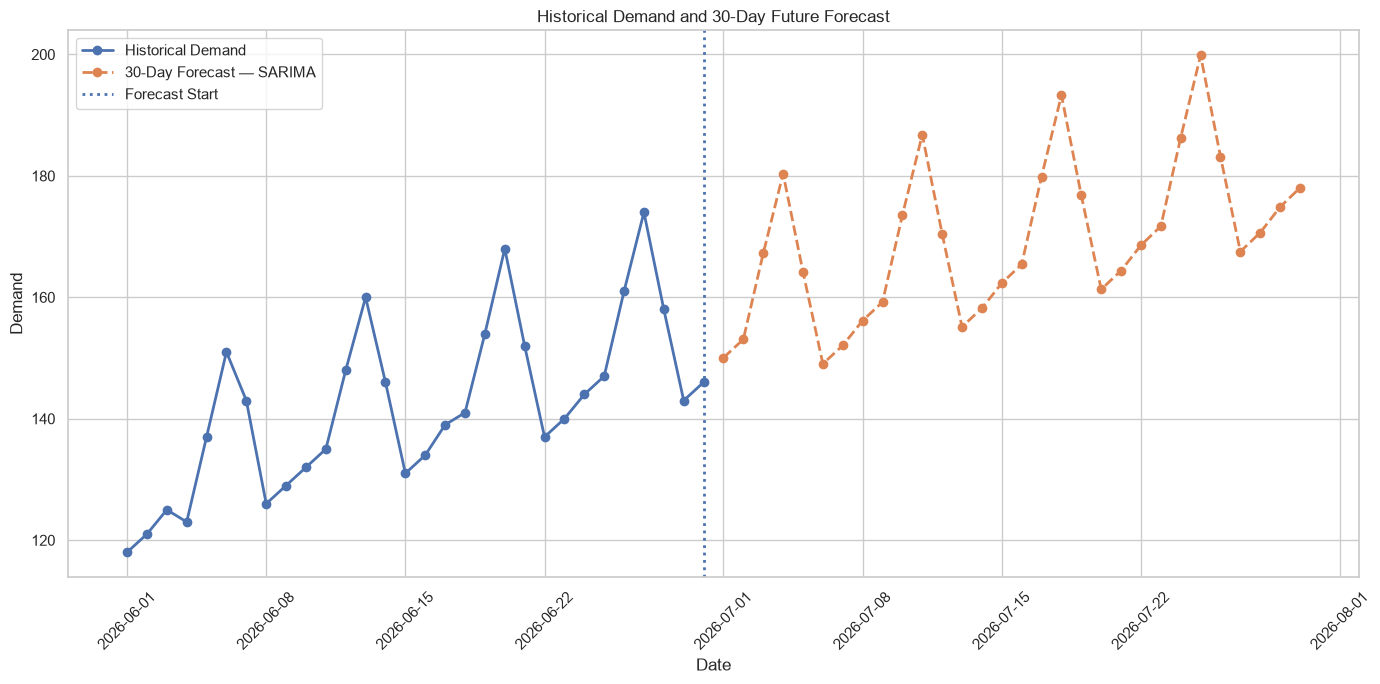

In [56]:
# Day 4 — Step 3: Plot 30-Day Future Forecast

plt.figure(figsize=(14, 7))

plt.plot(
    df["date"],
    df["demand"],
    marker="o",
    linewidth=2,
    label="Historical Demand"
)

plt.plot(
    future_forecast_df["date"],
    future_forecast_df["forecast_demand"],
    marker="o",
    linestyle="--",
    linewidth=2,
    label=f"30-Day Forecast — {final_model_name}"
)

plt.axvline(
    x=df["date"].max(),
    linestyle=":",
    linewidth=2,
    label="Forecast Start"
)

plt.title("Historical Demand and 30-Day Future Forecast")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [57]:
# Day 4 — Step 4: Save 30-Day Forecast

future_forecast_path = results_dir / "task6_30_day_future_forecast.csv"

future_forecast_df.to_csv(
    future_forecast_path,
    index=False
)

print("30-day future forecast saved successfully!")
print(f"File: {future_forecast_path}")

30-day future forecast saved successfully!
File: ..\results\task6_30_day_future_forecast.csv


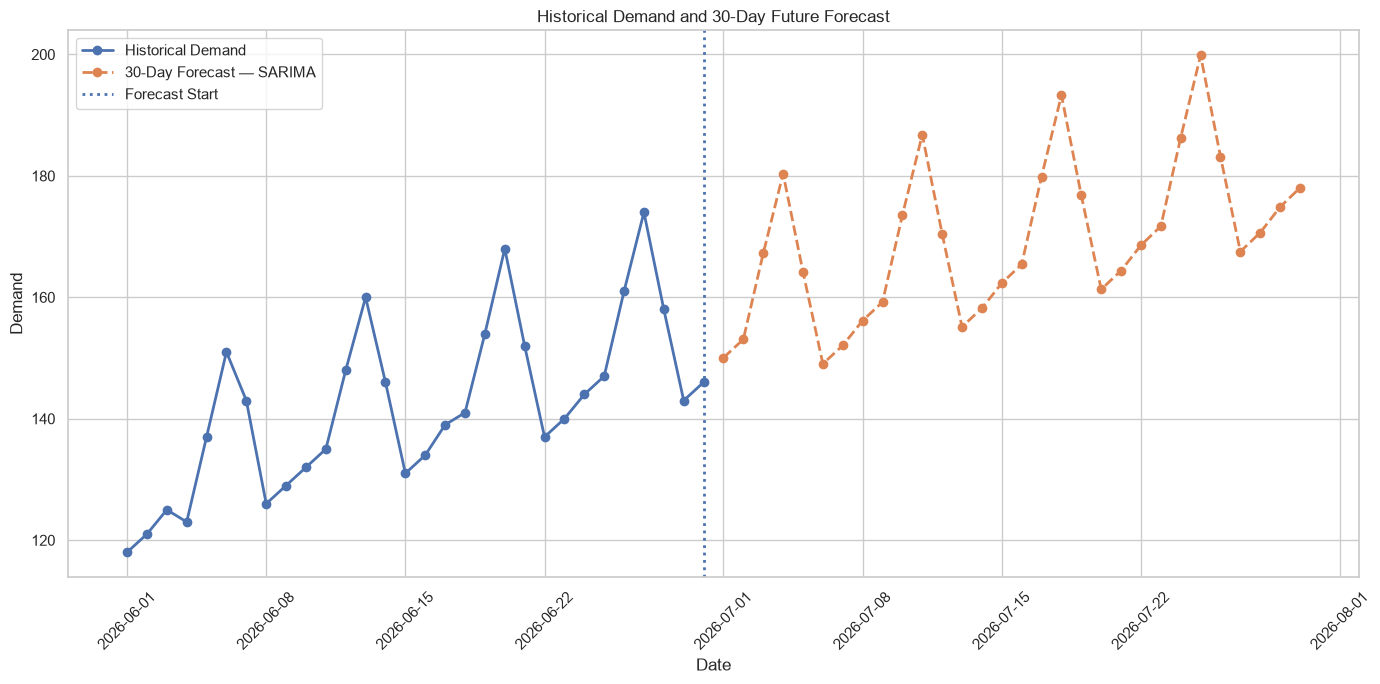

30-day forecast plot saved to: ..\plots\task6_30_day_future_forecast.png


In [58]:
# Day 4 — Step 5: Save 30-Day Forecast Plot

forecast_plot_path = plots_dir / "task6_30_day_future_forecast.png"

plt.figure(figsize=(14, 7))

plt.plot(
    df["date"],
    df["demand"],
    marker="o",
    linewidth=2,
    label="Historical Demand"
)

plt.plot(
    future_forecast_df["date"],
    future_forecast_df["forecast_demand"],
    marker="o",
    linestyle="--",
    linewidth=2,
    label=f"30-Day Forecast — {final_model_name}"
)

plt.axvline(
    x=df["date"].max(),
    linestyle=":",
    linewidth=2,
    label="Forecast Start"
)

plt.title("Historical Demand and 30-Day Future Forecast")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    forecast_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"30-day forecast plot saved to: {forecast_plot_path}")

In [59]:
# Day 4 — Step 6: Forecast Summary Statistics

forecast_mean = future_forecast_df["forecast_demand"].mean()
forecast_min = future_forecast_df["forecast_demand"].min()
forecast_max = future_forecast_df["forecast_demand"].max()
forecast_std = future_forecast_df["forecast_demand"].std()
forecast_range = forecast_max - forecast_min

forecast_summary = pd.DataFrame({
    "Statistic": [
        "Average Forecasted Demand",
        "Minimum Forecasted Demand",
        "Maximum Forecasted Demand",
        "Forecast Standard Deviation",
        "Forecast Range"
    ],
    "Value": [
        forecast_mean,
        forecast_min,
        forecast_max,
        forecast_std,
        forecast_range
    ]
})

forecast_summary

,Statistic,Value
0,Average Forecasted Demand,169.319309
1,Minimum Forecasted Demand,149.036393
2,Maximum Forecasted Demand,199.853069
3,Forecast Standard Deviation,12.926214
4,Forecast Range,50.816676


In [60]:
# Day 4 — Step 7: Save Forecast Summary

forecast_summary_path = results_dir / "task6_forecast_summary.csv"

forecast_summary.to_csv(
    forecast_summary_path,
    index=False
)

print("Forecast summary saved successfully!")
print(f"File: {forecast_summary_path}")

Forecast summary saved successfully!
File: ..\results\task6_forecast_summary.csv


## Business Implications

Demand forecasting can support operational and strategic decision-making by providing estimates of future demand.

The forecasting results can potentially help organizations with:

- Inventory and stock planning
- Workforce and resource allocation
- Procurement and supply planning
- Marketing and promotional planning
- Capacity management
- Short-term operational scheduling

The 30-day forecast provides an estimated view of future demand that can be used as a planning input.

However, forecast values should not be treated as exact outcomes. The relatively small dataset used in this study limits the reliability and generalizability of long-term predictions.

Additional historical observations, external business variables, and larger datasets would be required before deploying the forecasting approach in a production environment.

## Research Limitations

This study has several limitations that should be considered when interpreting the results.

1. **Small Dataset**  
   The dataset contains only a limited number of daily observations. A larger historical dataset would provide more reliable evidence of long-term patterns.

2. **Limited External Variables**  
   The available dataset contains marketing-event and holiday information, but does not include other potentially important factors such as weather, pricing, promotions, economic conditions, or competitor activity.

3. **Short Forecast Horizon**  
   The future forecast covers 30 days. Longer forecasting horizons may introduce greater uncertainty.

4. **Model Generalization**  
   The evaluated models were developed and tested on a single dataset. Their performance may differ when applied to other businesses, locations, or demand patterns.

5. **Limited Machine Learning Features**  
   The machine learning models were trained using a relatively small number of engineered features. Additional domain-specific features could potentially improve predictive performance.

6. **No Production Deployment**  
   The models were evaluated as part of a research workflow and were not deployed in a live production forecasting system.

Therefore, the findings should be considered exploratory and should be validated using larger and more diverse datasets before practical deployment.

## Research Conclusion

This study investigated the use of statistical time-series and machine learning approaches for daily demand forecasting.

The research workflow included data exploration, preprocessing, feature engineering, stationarity analysis, statistical forecasting, machine learning modeling, model evaluation, and future demand forecasting.

The evaluated models were compared using MAE, RMSE, and MAPE, with RMSE used as the primary model-selection criterion.

The final selected model provided the lowest test-set RMSE among the evaluated approaches and was subsequently used to generate a 30-day future demand forecast.

The findings demonstrate that data-driven forecasting can provide useful information for demand planning and operational decision-making. However, the relatively small dataset limits the generalizability of the findings.

Future research should use larger datasets and incorporate additional variables such as pricing, promotions, weather, holidays, economic conditions, and other business-specific factors. More advanced forecasting approaches could also be evaluated to determine whether predictive performance can be improved.

Overall, the study demonstrates a complete and reproducible data science workflow for investigating demand forecasting using both statistical and machine learning techniques.

## Saving Business & Research Summary

The main business implications, research limitations, and overall conclusion are recorded for use in the final research whitepaper.

In [61]:
# Day 4 — Step 11: Save Business & Research Summary

summary_path = results_dir / "task6_business_and_research_summary.txt"

with open(summary_path, "w", encoding="utf-8") as file:
    file.write("TASK 6 — BUSINESS & RESEARCH SUMMARY\n")
    file.write("=" * 60 + "\n\n")

    file.write("BUSINESS IMPLICATIONS\n")
    file.write("-" * 30 + "\n")
    file.write(
        "Demand forecasting can support inventory and stock planning, "
        "workforce allocation, procurement, marketing planning, capacity "
        "management, and short-term operational scheduling.\n\n"
    )

    file.write("RESEARCH LIMITATIONS\n")
    file.write("-" * 30 + "\n")
    file.write(
        "The study uses a relatively small dataset and a limited number "
        "of external variables. The forecast covers 30 days and the models "
        "were not deployed in a production environment. Therefore, the "
        "results should be considered exploratory.\n\n"
    )

    file.write("RESEARCH CONCLUSION\n")
    file.write("-" * 30 + "\n")
    file.write(
        "The study demonstrated a complete data science workflow for "
        "daily demand forecasting using statistical and machine learning "
        "approaches. Models were evaluated using MAE, RMSE, and MAPE, "
        "with RMSE used as the primary selection criterion. The selected "
        "model was used to generate a 30-day future demand forecast.\n\n"
    )

    file.write(
        "Future research should use larger datasets and additional "
        "business-specific variables to improve model reliability and "
        "generalizability.\n"
    )

print(f"Business and research summary saved to: {summary_path}")

Business and research summary saved to: ..\results\task6_business_and_research_summary.txt


# Day 5 — Research Report & Whitepaper Preparation

## Objective

The objective of Day 5 is to consolidate the complete research findings into a formal Data Science Research Report.

The final report will document the research question, background, methodology, exploratory analysis, predictive modeling, model evaluation, business implications, limitations, conclusion, and references.

The report will be prepared as a formal 8–12 page PDF whitepaper and will accompany the complete research repository.

## Final Research Report Structure

The final Data Science Research Report will follow a formal academic structure:

1. Abstract
2. Introduction
3. Research Question and Objectives
4. Background and Literature Review
5. Dataset and Data Methodology
6. Exploratory Data Analysis
7. Time-Series Analysis
8. Feature Engineering
9. Predictive Modeling
10. Model Evaluation and Results
11. Future Demand Forecast
12. Business Implications
13. Limitations
14. Conclusion
15. References

The report will combine statistical findings, machine learning results, visualizations, tables, and business interpretation to provide a complete research narrative.

## Abstract

This study investigates the effectiveness of statistical time-series and machine learning approaches for daily demand forecasting. The research uses a historical daily demand dataset containing demand observations along with marketing-event and holiday information. A complete data science workflow was implemented, including data exploration, preprocessing, feature engineering, time-series analysis, stationarity testing, predictive modeling, model evaluation, and future forecasting.

Several forecasting approaches were evaluated, including a naive baseline, ARIMA, SARIMA, Random Forest, and Gradient Boosting. Model performance was assessed using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE), with RMSE used as the primary model-selection criterion.

The best-performing model on the held-out test data was selected and subsequently refitted using the complete historical dataset to generate a 30-day future demand forecast. The study also examines potential business applications of demand forecasting, including inventory planning, resource allocation, procurement, and operational scheduling.

The results demonstrate the value of combining statistical and machine learning techniques within a reproducible forecasting workflow. However, the relatively small dataset limits the generalizability of the findings. Future research should incorporate larger datasets and additional explanatory variables to improve forecasting reliability and practical applicability.

## 1. Introduction

Demand forecasting is an important data science application that helps organizations estimate future demand using historical observations and relevant influencing factors. Accurate forecasts can support better operational planning, resource allocation, inventory management, procurement, and business decision-making.

Traditional statistical time-series models such as ARIMA and SARIMA are widely used for forecasting because they can model temporal dependencies, trends, and seasonal behavior. At the same time, machine learning algorithms such as Random Forest and Gradient Boosting can learn relationships between historical demand and engineered explanatory features.

This research investigates both statistical and machine learning approaches for predicting daily demand. The study follows a complete and reproducible data science workflow, beginning with data exploration and preprocessing and continuing through feature engineering, time-series analysis, predictive modeling, evaluation, and future forecasting.

The research uses a historical daily demand dataset containing demand observations together with marketing-event and holiday information. Additional temporal and lag-based features are engineered to support the machine learning models.

The central objective is not only to determine which model performs best on the available test data, but also to understand how forecasting results can be interpreted from a practical business perspective. The study therefore combines quantitative model evaluation with business-oriented interpretation.

Because the available dataset is relatively small, the research is treated as an exploratory forecasting study. The findings provide a structured demonstration of the forecasting workflow while highlighting the importance of larger datasets and additional explanatory variables for future research.

## 2. Research Question and Objectives

### Research Question

How effectively can statistical time-series and machine learning models predict future daily demand, and which approach provides the most reliable predictive performance?

### Research Objectives

The study has the following objectives:

1. Analyze historical daily demand patterns and identify important temporal characteristics.

2. Examine the stationarity and seasonal behavior of the demand series.

3. Develop meaningful temporal and lag-based features for predictive modeling.

4. Develop statistical forecasting models including ARIMA and SARIMA.

5. Develop machine learning forecasting models including Random Forest and Gradient Boosting.

6. Compare the predictive performance of the evaluated models using MAE, RMSE, and MAPE.

7. Select the best-performing model using test-set RMSE as the primary selection criterion.

8. Generate a 30-day future demand forecast using the selected model.

9. Interpret the forecasting results from a practical business perspective.

10. Document the limitations of the study and identify opportunities for future research.

## 3. Background and Literature Review

### 3.1 Demand Forecasting

Demand forecasting is the process of estimating future demand using historical observations and relevant explanatory information. It is widely used in areas such as retail, supply-chain management, inventory planning, capacity management, and operations.

Forecasting methods can generally be divided into statistical approaches and machine learning approaches. Statistical time-series methods explicitly model temporal structure, while machine learning methods can learn complex relationships from engineered features.

### 3.2 ARIMA

Autoregressive Integrated Moving Average (ARIMA) is a widely used statistical forecasting approach. ARIMA is represented using three parameters: p, d, and q.

- **p** represents the autoregressive component.
- **d** represents the degree of differencing.
- **q** represents the moving-average component.

ARIMA is particularly useful for univariate time-series forecasting when temporal dependencies and stationarity characteristics can be identified.

### 3.3 SARIMA

Seasonal ARIMA extends ARIMA by incorporating seasonal components. SARIMA is useful when observations contain recurring seasonal patterns.

In this study, weekly seasonality is considered because the data represents daily demand and may contain differences associated with the day of the week.

### 3.4 Machine Learning for Forecasting

Machine learning approaches can model nonlinear relationships between demand and explanatory features. In this research, Random Forest and Gradient Boosting are evaluated.

Random Forest combines multiple decision trees to produce predictions and can capture nonlinear relationships while reducing dependence on a single decision tree.

Gradient Boosting builds an ensemble of decision trees sequentially, where each new tree attempts to improve the errors made by previous trees.

### 3.5 Model Evaluation

Forecasting models should be evaluated using objective performance measures. This study uses:

- **Mean Absolute Error (MAE):** Measures the average absolute difference between actual and predicted values.
- **Root Mean Squared Error (RMSE):** Measures the square root of the average squared prediction error and gives greater weight to larger errors.
- **Mean Absolute Percentage Error (MAPE):** Expresses prediction error as a percentage of the actual values.

RMSE is used as the primary model-selection criterion in this research.

### 3.6 Research Gap

While statistical and machine learning forecasting methods are both widely established, their relative performance depends on the characteristics of the available data.

This study contributes a reproducible comparative workflow that evaluates statistical and machine learning approaches on the same daily demand dataset. The research also combines model evaluation with future forecasting and business interpretation.

The study therefore provides a practical framework for comparing different forecasting approaches while explicitly considering dataset limitations and model generalizability.

## 4. Dataset and Data Methodology

### 4.1 Dataset Description

The study uses a historical daily demand dataset containing three main types of information:

- **Date:** Daily observation date.
- **Demand:** Observed daily demand value used as the primary forecasting target.
- **Marketing Event:** Indicates whether a marketing event occurred.
- **Holiday:** Indicates whether the observation corresponds to a holiday.

The dataset contains 30 daily observations covering a continuous time period.

### 4.2 Data Quality Assessment

The dataset was examined for:

- Missing values
- Duplicate observations
- Data types
- Date continuity
- Descriptive statistics
- Minimum and maximum demand values

The date column was converted to a proper datetime format and the observations were sorted chronologically.

### 4.3 Exploratory Data Analysis

Exploratory analysis was performed to understand the distribution and behavior of daily demand.

The analysis included:

- Descriptive statistics
- Daily demand trend visualization
- Demand comparison by marketing-event status
- Demand comparison by holiday status
- Weekly seasonality analysis
- Correlation analysis

### 4.4 Feature Engineering

Additional temporal and historical features were created for machine learning models.

The engineered features included:

- Day of week
- Day of month
- Month
- Week of year
- One-day lag demand
- Seven-day lag demand
- Seven-day rolling mean
- Seven-day rolling standard deviation

Rolling statistics were calculated using shifted values to prevent information from the current observation from leaking into the prediction.

### 4.5 Train-Test Strategy

Because the data represents a time series, observations were not randomly shuffled.

An 80/20 time-ordered train-test split was used. Earlier observations were used for training, while the most recent observations were reserved for testing.

This approach better represents a real forecasting scenario because future observations are not available when the model is trained.

After feature engineering, 23 usable observations remained, with 18 observations used for training and 5 observations used for testing in the machine learning workflow.

### 4.6 Reproducibility

The complete data preparation, feature engineering, modeling, evaluation, visualization, and forecasting workflow is implemented in the project Jupyter Notebook.

All major intermediate results and final outputs are saved in structured CSV and image files within the research repository.

## 5. Exploratory Data Analysis

Exploratory Data Analysis (EDA) was performed to understand the historical demand behavior before developing predictive models.

### 5.1 Demand Distribution

The daily demand series was examined using descriptive statistics and visualizations. The analysis helped identify the central tendency, variability, and overall range of demand values.

### 5.2 Demand Trend

A daily demand time-series plot was created to visualize changes in demand over time. This provided an initial understanding of fluctuations and possible temporal patterns.

### 5.3 Marketing Events

Demand was compared between observations with and without marketing events. This analysis was used to investigate whether marketing-event periods showed visibly different demand behavior.

### 5.4 Holidays

Demand distributions were also compared between holiday and non-holiday observations. This provided an initial assessment of whether holidays may be associated with changes in demand.

### 5.5 Weekly Seasonality

Daily demand was grouped by day of the week to identify recurring weekly patterns.

The analysis provides evidence about whether particular days tend to have higher or lower average demand. These observations were considered when interpreting the forecasting results.

### 5.6 Correlation Analysis

A correlation matrix was calculated for the numerical variables and engineered features.

Correlation analysis was used as an exploratory tool to identify relationships between demand and available numerical predictors. Correlation alone was not treated as evidence of causation.

### EDA Interpretation

The exploratory analysis established the foundation for subsequent time-series analysis and predictive modeling. The observed temporal behavior, weekly patterns, and available business indicators were considered when designing the forecasting workflow.

## 6. Time-Series Analysis

Time-series analysis was performed to understand the temporal properties of the daily demand series before applying statistical forecasting models.

### 6.1 Time-Series Decomposition

The demand series was decomposed using an additive seasonal decomposition with a weekly period of 7 days.

The decomposition separates the observed series into:

- Trend
- Seasonal component
- Residual component

This provides a clearer view of underlying trends and recurring weekly patterns.

### 6.2 Stationarity Analysis

Stationarity was evaluated using the Augmented Dickey-Fuller (ADF) test.

The ADF test was first applied to the original demand series. First-order differencing was then performed and the ADF test was applied again.

The differencing step was used to determine whether the series became more suitable for ARIMA-based modeling.

### 6.3 First-Order Differencing

First-order differencing was calculated as the difference between consecutive demand observations.

Differencing helps remove changes in the level of the series and can make a non-stationary time series more suitable for statistical forecasting.

### 6.4 Weekly Seasonality

Weekly seasonality was investigated by calculating average demand for each day of the week.

This analysis was particularly relevant because the dataset contains daily observations and recurring weekly behavior may influence demand.

### 6.5 Interpretation

The time-series analysis provided important information for selecting the differencing order and considering seasonal behavior in the forecasting models.

The results were subsequently used when developing ARIMA and SARIMA models.

## 7. Predictive Modeling

Five forecasting approaches were evaluated to provide a comprehensive comparison between simple, statistical, and machine learning methods.

### 7.1 Naive Baseline

A naive forecasting method was used as a baseline.

The baseline assumes that the next demand value can be estimated using the previous observed demand value.

This provides a simple reference point against which more advanced models can be compared.

### 7.2 ARIMA

ARIMA models were evaluated using several combinations of the parameters p, d, and q.

The differencing order was set to 1 based on the stationarity analysis.

The following configurations were tested:

- ARIMA(0,1,0)
- ARIMA(0,1,1)
- ARIMA(1,1,0)
- ARIMA(1,1,1)
- ARIMA(2,1,0)
- ARIMA(2,1,1)

The configuration with the lowest test-set RMSE was selected.

### 7.3 SARIMA

SARIMA was used to account for potential weekly seasonal behavior.

The evaluated configuration used:

- Non-seasonal order: (1,1,0)
- Seasonal order: (1,0,0,7)

The seasonal period of 7 represents a weekly cycle for daily observations.

### 7.4 Random Forest

A Random Forest Regressor was developed using the engineered temporal and lag-based features.

The model used multiple decision trees to capture nonlinear relationships between historical demand patterns and the target demand.

### 7.5 Gradient Boosting

A Gradient Boosting Regressor was also evaluated.

The model builds decision trees sequentially, with each successive tree attempting to reduce prediction errors from the previous stage.

### 7.6 Model Comparison

All models were evaluated on the held-out test data using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)

RMSE was selected as the primary criterion for determining the final predictive model.

The complete model comparison is stored in:

`results/task6_complete_model_comparison.csv`

## 8. Model Performance and Results

The predictive models were evaluated on held-out test observations that were not used during model training.

Three evaluation metrics were used:

- **MAE:** Represents the average absolute prediction error.
- **RMSE:** Represents the square root of the average squared prediction error and places greater emphasis on larger errors.
- **MAPE:** Represents prediction error as a percentage of the observed demand.

### Model Selection

The models were ranked according to test-set RMSE. The model with the lowest RMSE was selected as the final predictive model.

The complete performance comparison is available in:

`results/task6_complete_model_comparison.csv`

The final model's detailed test predictions are available in:

`results/task6_final_model_predictions.csv`

### Interpretation

The comparison provides evidence about how different forecasting approaches perform on the available dataset.

The results should be interpreted within the context of the study design. In particular, the dataset contains a relatively small number of observations, meaning that performance differences between models should not automatically be interpreted as evidence that one approach will always outperform another dataset or business environment.

The evaluation therefore provides an exploratory comparison of statistical and machine learning forecasting methods under the specific conditions of this study.

## 9. Future Demand Forecast and Business Implications

After selecting the final predictive model, the model was refitted using the complete historical demand series.

A 30-day future demand forecast was then generated to provide a forward-looking estimate of expected demand.

### 9.1 Future Forecast

The future forecast contains daily demand estimates for the 30 days following the final observed date.

The forecast is stored in:

`results/task6_30_day_future_forecast.csv`

A visualization of the historical demand and future forecast is stored in:

`plots/task6_30_day_future_forecast.png`

### 9.2 Business Applications

Demand forecasting can support several operational activities:

- **Inventory Planning:** Forecasts can help organizations prepare appropriate inventory levels.
- **Resource Allocation:** Expected demand can support workforce and resource planning.
- **Procurement:** Future demand estimates can assist purchasing decisions.
- **Marketing:** Demand patterns can help evaluate and plan promotional activities.
- **Capacity Management:** Forecasts can support decisions about operational capacity.
- **Scheduling:** Short-term demand estimates can assist operational scheduling.

### 9.3 Forecast Interpretation

The 30-day forecast should be interpreted as an estimated future demand trajectory rather than a guaranteed outcome.

Forecast uncertainty can increase as the prediction horizon becomes longer. Therefore, organizations should combine model predictions with domain knowledge and newly observed data when making operational decisions.

The forecast summary statistics are stored in:

`results/task6_forecast_summary.csv`

## 10. Limitations and Future Research

### 10.1 Limitations

Several limitations should be considered when interpreting the findings of this study.

**Small Sample Size:**  
The dataset contains only 30 daily observations. This limits the ability of the models to learn long-term patterns and reduces the generalizability of the results.

**Limited Explanatory Variables:**  
The dataset contains marketing-event and holiday information but does not include other potentially important variables such as price, weather, promotions, economic conditions, competitor activity, or customer-level information.

**Short Historical Period:**  
The available historical period is relatively short for identifying long-term seasonal and cyclical patterns.

**Forecast Uncertainty:**  
Future forecasts become increasingly uncertain as the prediction horizon increases. The 30-day forecast should therefore be treated as an estimate rather than an exact prediction.

**Model Generalization:**  
The models were evaluated on one dataset and one forecasting problem. Their performance may differ when applied to other organizations, industries, locations, or demand patterns.

**No Production Deployment:**  
The research evaluates the models in an analytical environment and does not include real-time production deployment or continuous model monitoring.

### 10.2 Future Research

Future research could improve the study by:

1. Collecting a substantially larger historical dataset.
2. Including multiple years of observations to capture seasonal patterns.
3. Incorporating external variables such as price, weather, promotions, and economic indicators.
4. Testing additional forecasting models.
5. Performing rolling or walk-forward validation.
6. Evaluating prediction intervals and forecast uncertainty.
7. Performing systematic hyperparameter optimization.
8. Testing the models on datasets from different business environments.
9. Deploying the selected model as a real-time forecasting service.
10. Implementing continuous monitoring and periodic model retraining.

## 11. Conclusion

This research investigated the effectiveness of statistical time-series and machine learning approaches for daily demand forecasting.

A complete and reproducible data science workflow was implemented, including data quality assessment, exploratory data analysis, time-series decomposition, stationarity testing, feature engineering, predictive modeling, model evaluation, and future forecasting.

Five approaches were evaluated: a naive baseline, ARIMA, SARIMA, Random Forest, and Gradient Boosting. Their predictive performance was measured using MAE, RMSE, and MAPE, with RMSE selected as the primary model-selection criterion.

The best-performing model on the held-out test data was selected and refitted using the complete historical dataset. A 30-day future demand forecast was then generated using the selected model.

The research demonstrates how combining statistical forecasting and machine learning methods can provide a structured approach to demand prediction. The resulting forecasts may support operational activities such as inventory planning, resource allocation, procurement, and capacity management.

However, the study is exploratory because of the limited size and scope of the available dataset. The findings should therefore not be generalized to other business environments without additional validation.

Future work should use larger datasets, longer historical periods, additional explanatory variables, stronger time-series validation methods, and more advanced forecasting techniques.

Overall, the project demonstrates a complete data science research workflow from research question formulation through predictive modeling, evaluation, interpretation, and future forecasting.

## 12. References

1. Box, G. E. P., Jenkins, G. M., Reinsel, G. C., & Ljung, G. M. (2015). *Time Series Analysis: Forecasting and Control*. Wiley.

2. Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3rd ed.). OTexts.

3. Breiman, L. (2001). Random Forests. *Machine Learning, 45*, 5–32.

4. Friedman, J. H. (2001). Greedy Function Approximation: A Gradient Boosting Machine. *The Annals of Statistics, 29*(5), 1189–1232.

5. Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

6. Seabold, S., & Perktold, J. (2010). Statsmodels: Econometric and Statistical Modeling with Python. *Proceedings of the 9th Python in Science Conference*.

7. McKinney, W. (2010). Data Structures for Statistical Computing in Python. *Proceedings of the 9th Python in Science Conference*.

8. Hunter, J. D. (2007). Matplotlib: A 2D Graphics Environment. *Computing in Science & Engineering, 9*(3), 90–95.

9. Harris, C. R., et al. (2020). Array Programming with NumPy. *Nature, 585*, 357–362.

10. Waskom, M. L. (2021). Seaborn: Statistical Data Visualization. *Journal of Open Source Software, 6*(60), 3021.

## Final Research Findings Summary

This section consolidates the major findings from the complete research workflow.

The study examined daily demand using exploratory analysis, time-series analysis, statistical forecasting, and machine learning.

The predictive models were evaluated using MAE, RMSE, and MAPE. The model with the lowest test-set RMSE was selected as the final predictive model.

The selected model was subsequently refitted using the complete historical dataset and used to generate a 30-day future demand forecast.

The research also identified important practical applications of demand forecasting, including inventory planning, resource allocation, procurement, capacity management, and operational scheduling.

Due to the limited number of observations and available explanatory variables, the results should be interpreted as exploratory findings. Future studies should use larger datasets, longer historical periods, additional business variables, and stronger validation strategies.

The detailed numerical results are stored in the project's results directory and the supporting visualizations are stored in the plots directory.

In [62]:
# Day 5 — Step 21: Generate Final Report Results Table

report_results = all_model_metrics.copy()

# Format numerical values
report_results["MAE"] = report_results["MAE"].round(4)
report_results["RMSE"] = report_results["RMSE"].round(4)
report_results["MAPE (%)"] = report_results["MAPE (%)"].round(2)

# Display final results
print("FINAL MODEL PERFORMANCE")
print("=" * 60)
display(report_results[["Model", "MAE", "RMSE", "MAPE (%)"]])

print("\nSELECTED FINAL MODEL")
print("=" * 60)
print(f"Model : {final_model_name}")
print(f"MAE   : {final_mae:.4f}")
print(f"RMSE  : {final_rmse:.4f}")
print(f"MAPE  : {final_mape:.2f}%")

FINAL MODEL PERFORMANCE


,Model,MAE,RMSE,MAPE (%)
0,SARIMA,0.8887,0.9622,0.58
1,Gradient Boosting,2.2463,3.1660,1.37
2,Random Forest,3.5783,5.4669,2.15
3,Naive Baseline,12.2000,13.0767,7.77
4,Selected ARIMA,10.4440,14.4857,6.35



SELECTED FINAL MODEL
Model : SARIMA
MAE   : 0.8887
RMSE  : 0.9622
MAPE  : 0.58%


In [63]:
# Day 5 — Step 22: Save Final Report Results

report_results_path = results_dir / "task6_final_report_results.csv"

report_results.to_csv(
    report_results_path,
    index=False
)

print("Final report results saved successfully!")
print(f"File: {report_results_path}")

Final report results saved successfully!
File: ..\results\task6_final_report_results.csv
